# IEEE-CIS Fraud Detection - Preprocessing and Model Comparison

This notebook compares different types of machine learning models on the
IEEE-CIS Fraud Detection dataset downloaded from Kaggle. The labelled dataset has two files, `train_transaction.csv`
and `train_identity.csv`, which are merged together using `TransactionID`.

Nine models across different categories were evaluated:

- Baseline: Logistic Regression
- Bagging: Random Forest
- Boosting: XGBoost
- Boosting: CatBoost
- Neural network (supervised): MLP
- Classical anomaly detection: Isolation Forest
- Deep anomaly detection: Autoencoder
- Ensemble: Soft Voting
- Ensemble: Stacking



# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 2. Load data

In [2]:
# === DATA PATH ===
BASE_DIR = Path("/Users/lata.bharati/Desktop/FraudShield")
DATA_FOLDER = BASE_DIR / "IEEE-CIS Fraud Detection Raw Datasets"

def load_fraud_data(data_folder=DATA_FOLDER):
    data_folder = Path(data_folder)
    print("Data folder:", data_folder)
    print("Folder exists:", data_folder.exists())

    train_transaction = pd.read_csv(data_folder / "train_transaction.csv")
    train_identity = pd.read_csv(data_folder / "train_identity.csv")

    print("Transaction data shape:", train_transaction.shape)
    print("Identity data shape:", train_identity.shape)
    return train_transaction, train_identity

In [3]:
train_transaction, train_identity = load_fraud_data()

Data folder: /Users/lata.bharati/Desktop/FraudShield/IEEE-CIS Fraud Detection Raw Datasets
Folder exists: True
Transaction data shape: (590540, 394)
Identity data shape: (144233, 41)


# 3. Merge transaction and identity data 

In [4]:
transaction_df = train_transaction.copy()
identity_df = train_identity.copy()

# Add a column to show identity data is available
identity_df["has_identity"] = 1

# Merge transaction and identity data using TransactionID
df = transaction_df.merge(identity_df, on="TransactionID", how="left")

# If identity data is not available replace NaN with 0
df["has_identity"] = df["has_identity"].fillna(0).astype("int8")

print("Transaction data shape:", transaction_df.shape)
print("Identity data shape:", identity_df.shape)
print("Merged data shape:", df.shape)

# Check identity availability
print("Without identity data:", (df["has_identity"] == 0).sum())
print("With identity data:", (df["has_identity"] == 1).sum())

Transaction data shape: (590540, 394)
Identity data shape: (144233, 42)
Merged data shape: (590540, 435)
Without identity data: 446307
With identity data: 144233


In [5]:
pd.set_option('display.max_columns',435)
df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.

In [6]:
df_merged = df.copy()

In [7]:
# Sort transactions using the relative transaction time
df_sorted = df_merged.sort_values('TransactionDT').reset_index(drop=True)
print(df_sorted.shape)

print("\nFraud percentage:")
print(df_sorted["isFraud"].value_counts(normalize=True) * 100)

(590540, 435)

Fraud percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


# 4. Temporal Train-Validation-Test Split

The dataset was divided chronologically into training (60%), validation (20%) and test (20%) sets using TransactionDT. 

In [8]:
train_end = int(len(df_sorted) * 0.60)
validation_end = int(len(df_sorted) * 0.80)

train_set = df_sorted.iloc[:train_end].copy()
valid_set = df_sorted.iloc[train_end:validation_end].copy()
test_set = df_sorted.iloc[validation_end:].copy()

print("Training shape:", train_set.shape)
print("Validation shape:", valid_set.shape)
print("Test shape:", test_set.shape)

Training shape: (354324, 435)
Validation shape: (118108, 435)
Test shape: (118108, 435)


In [9]:
for name, data in {"Training": train_set, "Validation": valid_set, "Test": test_set}.items():
    fraud_percentage = data["isFraud"].mean() * 100
    print(
        f"{name}: {len(data):,} transactions, "
        f"{fraud_percentage:.2f}% fraud"
    )

Training: 354,324 transactions, 3.38% fraud
Validation: 118,108 transactions, 3.90% fraud
Test: 118,108 transactions, 3.44% fraud


In [10]:
# Applying log transformation to transaction amount
for data in [train_set, valid_set, test_set]:
    data["TransactionAmt_log"] = np.log1p(data["TransactionAmt"])

Log transformation was applied to "TransactionAmt" because its distribution was highly right-skewed.

In [11]:
for data in [train_set, valid_set, test_set]:
    data.drop(columns=["TransactionAmt"], inplace=True)

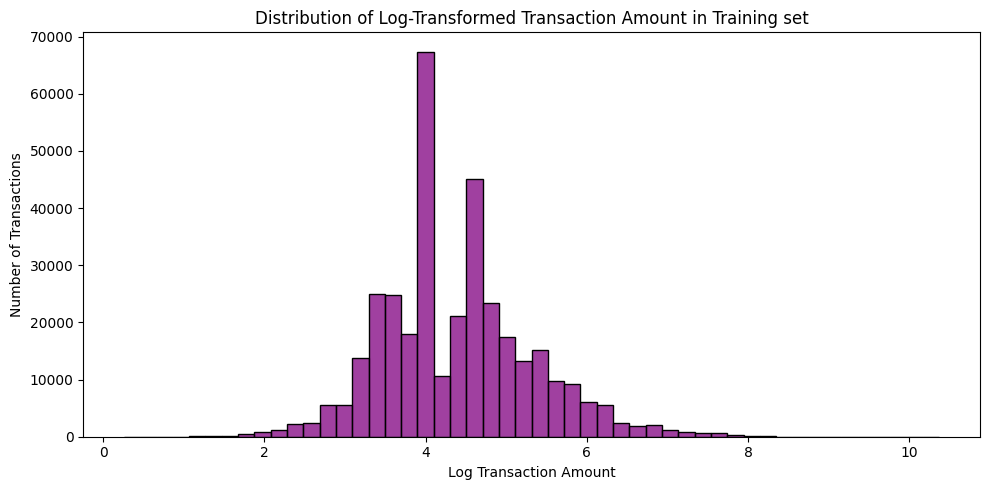

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(train_set["TransactionAmt_log"], bins=50, color="purple")
plt.title("Distribution of Log-Transformed Transaction Amount in Training set")
plt.xlabel("Log Transaction Amount")
plt.ylabel("Number of Transactions")
plt.grid(False)
plt.tight_layout()
plt.show()

# 5. Preprocessing using training data only

Columns with over 90% missing values were dropped based on the training set alone. We have used frequency encoding for categorical variables using training-set frequencies, and filled any remaining missing values with the median of each column from the training data. To prevent data leakage, the exact same preprocessing steps were then applied to the validation and test sets.

In [13]:
# Separate target variable
y_train = train_set["isFraud"].copy()
y_valid = valid_set["isFraud"].copy()
y_test = test_set["isFraud"].copy()

# Engineer simple relative time-cycle features before dropping raw TransactionDT.
for data in [train_set, valid_set, test_set]:
    data["RelativeHour"] = (data["TransactionDT"] // 3600) % 24
    data["RelativeWeekday"] = (data["TransactionDT"] // (3600 * 24)) % 7

# Columns not used as model features
drop_cols = ["TransactionID", "isFraud", "TransactionDT"]
drop_cols = [col for col in drop_cols if col in train_set.columns]

X_train = train_set.drop(columns=drop_cols).copy()
X_valid = valid_set.drop(columns=drop_cols).copy()
X_test = test_set.drop(columns=drop_cols).copy()

In [14]:
print(X_train.shape)
print(y_train.shape)

(354324, 434)
(354324,)


In [15]:
print(X_valid.shape)
print(X_test.shape)

(118108, 434)
(118108, 434)


In [16]:
# Calculate missing values in training data
missing_percentage = (X_train.isnull().mean() * 100).sort_values(ascending=False)
display(missing_percentage.head(50))

id_24    99.076551
id_25    99.005712
id_08    99.002043
id_07    99.002043
id_26    99.001479
id_21    99.000914
id_23    98.999786
id_22    98.999786
id_27    98.999786
D7       93.773778
dist2    92.517301
id_18    91.467696
D13      89.853919
D14      89.476299
D12      89.034612
id_03    87.721408
id_04    87.721408
D6       87.693467
D8       85.967081
D9       85.967081
id_10    85.967081
id_09    85.967081
id_33    84.883609
id_30    83.730428
id_32    83.724783
id_34    83.710954
id_14    83.264470
V142     82.828146
V141     82.828146
V140     82.828146
V139     82.828146
V138     82.828146
V143     82.828146
V144     82.828146
V156     82.828146
V158     82.828146
V159     82.828146
V160     82.828146
V145     82.828146
V161     82.828146
V162     82.828146
V163     82.828146
V164     82.828146
V165     82.828146
V166     82.828146
V157     82.828146
V155     82.828146
V154     82.828146
V153     82.828146
V152     82.828146
dtype: float64

In [17]:
# Find features with more than 90% missing values
high_missing_cols = missing_percentage[missing_percentage > 90].index.tolist()
print("Number of features:", len(high_missing_cols))
print(high_missing_cols)

Number of features: 12
['id_24', 'id_25', 'id_08', 'id_07', 'id_26', 'id_21', 'id_23', 'id_22', 'id_27', 'D7', 'dist2', 'id_18']


In [18]:
# Drop high-missing columns from train, validation and test
X_train = X_train.drop(columns=high_missing_cols)
X_valid = X_valid.drop(columns=high_missing_cols)
X_test = X_test.drop(columns=high_missing_cols)

In [19]:
print("X_train shape after dropping high-missing columns:", X_train.shape)
print("X_valid shape after dropping high-missing columns:", X_valid.shape)
print("X_test shape after dropping high-missing columns:", X_test.shape)

X_train shape after dropping high-missing columns: (354324, 422)
X_valid shape after dropping high-missing columns: (118108, 422)
X_test shape after dropping high-missing columns: (118108, 422)


## 5.1 Frequency Encoding of Categorical Features

In [20]:
# Categorical features based on the dataset description(as per information available on Kaggle)
categorical_features = (["ProductCD"] + [f"card{i}" for i in range(1, 7)] + ["addr1", "addr2", "P_emaildomain", "R_emaildomain"]  + [f"M{i}" for i in range(1, 10)] 
                        + ["DeviceType", "DeviceInfo"] + [f"id_{i:02d}" for i in range(12, 39)])

categorical_features = [col for col in categorical_features if col in df_sorted.columns]

# Numerical features
numerical_features = [
    col for col in df_sorted.columns
    if col not in categorical_features
    and col not in ["TransactionID", "isFraud"]
]

print("Categorical features:", len(categorical_features))
print(categorical_features)

print("\nNumerical features:", len(numerical_features))
print(numerical_features)

Categorical features: 49
['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

Numerical features: 384
['TransactionDT', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V

In [21]:
# update categorical features
categorical_features = [
    col for col in categorical_features
    if col in X_train.columns
]

print("Categorical features:", len(categorical_features))
print(categorical_features)

Categorical features: 41
['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_19', 'id_20', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


In [22]:
# Make copies of the before encoding
X_train_encoded = X_train.copy()
X_valid_encoded = X_valid.copy()
X_test_encoded = X_test.copy()

# Store frequency maps
frequency_maps = {}
for col in categorical_features:
    X_train_encoded[col] = X_train_encoded[col].astype("string").fillna("MISSING")
    X_valid_encoded[col] = X_valid_encoded[col].astype("string").fillna("MISSING")
    X_test_encoded[col] = X_test_encoded[col].astype("string").fillna("MISSING")

    # Learn frequency from training data only
    frequency_map = X_train_encoded[col].value_counts(normalize=True)

    # SAVE THE ACTUAL TRAINING MAP
    frequency_maps[col] = frequency_map.to_dict()

    # Apply same mapping to train, validation and test
    X_train_encoded[col] = X_train_encoded[col].map(frequency_map)
    X_valid_encoded[col] = X_valid_encoded[col].map(frequency_map)
    X_test_encoded[col] = X_test_encoded[col].map(frequency_map)

    # New/unseen categories in validation/test are filled with 0
    X_valid_encoded[col] = X_valid_encoded[col].fillna(0)
    X_test_encoded[col] = X_test_encoded[col].fillna(0)

print("Encoding completed.")

Encoding completed.


In [23]:
remaining_categorical = X_train_encoded.select_dtypes(
    exclude="number"
).columns.tolist()

print("Remaining categorical columns:")
print(remaining_categorical)

Remaining categorical columns:
[]


## 5.2 Median Imputation

In [24]:
# Calculate median using the training data
train_medians = X_train_encoded.median().fillna(0)

# Apply median imputation
X_train_ready = X_train_encoded.fillna(train_medians)
X_valid_ready = X_valid_encoded.fillna(train_medians)
X_test_ready = X_test_encoded.fillna(train_medians)

print("Missing values in train:", X_train_ready.isnull().sum().sum())
print("Missing values in validation:", X_valid_ready.isnull().sum().sum())
print("Missing values in test:", X_test_ready.isnull().sum().sum())

Missing values in train: 0
Missing values in validation: 0
Missing values in test: 0


## 5.3 Final Preprocessed Data Shapes

In [25]:
print("Final training data shape:", X_train_ready.shape)
print("Final validation data shape:", X_valid_ready.shape)
print("Final test data shape:", X_test_ready.shape)

print("\nTarget shapes:")
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)
print("y_test:", y_test.shape)

Final training data shape: (354324, 422)
Final validation data shape: (118108, 422)
Final test data shape: (118108, 422)

Target shapes:
y_train: (354324,)
y_valid: (118108,)
y_test: (118108,)


## 5.4 Correlation and Feature Reduction


Highly correlated features can add duplicate information and increase model complexity. Correlation was calculated using only the training set, and the same selected columns were removed from the validation and test sets.

### 5.4.1 Identify Highly Correlated Features

In [26]:
# Columns that should not be used for correlation-based removal
exclude_from_correlation = (categorical_features + ["has_identity", "RelativeHour", "RelativeWeekday"])

exclude_from_correlation = [
    col for col in exclude_from_correlation
    if col in X_train_ready.columns
]

# Numerical features for correlation analysis
correlation_features = [
    col for col in X_train_ready.columns
    if col not in exclude_from_correlation
]

print("Features used for correlation:", len(correlation_features))

Features used for correlation: 378


In [27]:
# Correlation check using training data only

corr_threshold = 0.95
corr_matrix = X_train_ready[correlation_features].corr().abs()

# Keep only upper triangle of correlation matrix
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation greater than threshold
high_corr_cols = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > corr_threshold)
]

print("Correlation threshold:", corr_threshold)
print("Number of highly correlated columns to remove:", len(high_corr_cols))
print(high_corr_cols)

Correlation threshold: 0.95
Number of highly correlated columns to remove: 78
['C2', 'C4', 'C6', 'C7', 'C8', 'C10', 'C11', 'C12', 'C14', 'V11', 'V16', 'V18', 'V21', 'V22', 'V28', 'V30', 'V32', 'V33', 'V34', 'V40', 'V43', 'V49', 'V52', 'V58', 'V60', 'V64', 'V70', 'V72', 'V73', 'V74', 'V81', 'V85', 'V91', 'V93', 'V94', 'V137', 'V145', 'V150', 'V151', 'V152', 'V154', 'V155', 'V156', 'V159', 'V160', 'V163', 'V165', 'V182', 'V187', 'V192', 'V193', 'V196', 'V199', 'V203', 'V207', 'V212', 'V222', 'V225', 'V229', 'V244', 'V249', 'V251', 'V253', 'V254', 'V256', 'V269', 'V272', 'V276', 'V292', 'V294', 'V295', 'V304', 'V317', 'V321', 'V333', 'V334', 'V336', 'V339']


In [28]:
# Full feature set
X_train_full = X_train_ready.copy()
X_valid_full = X_valid_ready.copy()
X_test_full = X_test_ready.copy()

# Reduced feature set
X_train_reduced = X_train_ready.drop(columns=high_corr_cols)

X_valid_reduced = X_valid_ready.drop(columns=high_corr_cols)

X_test_reduced = X_test_ready.drop(columns=high_corr_cols)

print("Full training shape:", X_train_full.shape)
print("Reduced training shape:", X_train_reduced.shape)

Full training shape: (354324, 422)
Reduced training shape: (354324, 344)


### 5.4.2 Highly Correlated Feature Pairs

In [29]:
high_corr_pairs = []

for col in upper_triangle.columns:
    correlated_rows = upper_triangle.index[upper_triangle[col] > corr_threshold].tolist()
    
    for row in correlated_rows:
        high_corr_pairs.append({ "Feature 1": row, "Feature 2": col, "Correlation": upper_triangle.loc[row, col] })

high_corr_table = pd.DataFrame(high_corr_pairs)
high_corr_table = high_corr_table.sort_values("Correlation", ascending=False)

display(high_corr_table.head(20))

,Feature 1,Feature 2,Correlation
27,C7,C12,0.999636
17,C8,C10,0.997532
18,C1,C11,0.996982
108,V266,V269,0.996969
19,C2,C11,0.996032
0,C1,C2,0.995877
21,C6,C11,0.993939
40,V27,V28,0.992184
16,C7,C10,0.991478
60,V92,V93,0.990433


Highly correlated features were identified using the training set only. Features with correlation above 0.95 were removed to reduce redundancy and simplify the modelling process. The same columns were removed from the validation and test sets to ensure consistent feature structure.

The class imbalance was handled only after the temporal train-validation-test split. The validation and test sets were kept in their original imbalanced form to represent realistic fraud detection conditions. During modelling, class-weighted models, scale_pos_weight, and anomaly detection methods were used to address the minority fraud class.

# 6. Scaling

Two feature versions were retained. The reduced feature set was used for models more sensitive to redundant or scaled features, such as Logistic Regression, MLP, Isolation Forest and Autoencoder. Tree-based models were trained using the full feature set because they are generally less sensitive to correlated variables.

In [30]:
from sklearn.preprocessing import StandardScaler

# LR / MLP / Autoencoder need scaled features [Fitting scaler on training data only]
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reduced)
X_valid_scaled = scaler.transform(X_valid_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_valid_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (354324, 344)
Scaled validation shape: (118108, 344)
Scaled test shape: (118108, 344)


In [31]:
# Check for missing values before proceeding to modelling
print("Train missing:", np.isnan(X_train_scaled).sum())
print("Validation missing:", np.isnan(X_valid_scaled).sum())
print("Test missing:", np.isnan(X_test_scaled).sum())

Train missing: 0
Validation missing: 0
Test missing: 0


# 7. Modelling

In [32]:
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve)
# Store model results
model_scores = {}
test_probs = {}
val_probs = {}
model_thresholds = {}

def evaluate_model(name, y_true, y_prob, threshold=0.5):

    # convert probabilities to binary predictions
    y_pred = (y_prob >= threshold).astype(int)

    scores = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

    # Save results
    model_scores[name] = scores
    test_probs[name] = y_prob
    model_thresholds[name] = threshold

    print(name)
    print("  Threshold:", round(threshold, 4))

    for metric, score in scores.items():
        print(metric, ":", round(score, 4))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()


def find_best_threshold(y_true, y_prob):
    # Get precision, recall and thresholds from the precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    # Calculate F1 score at each threshold
    f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    
    # Find threshold with highest F1
    best_index = np.argmax(f1_scores)

    print("Best F1-score:", round(f1_scores[best_index], 4))

    return thresholds[best_index]

### Decision Threshold Selection

For each model, the classification threshold was selected using the validation set by choosing the threshold that maximised the F1-score.

The test set was not used during threshold selection.

ROC-AUC and PR-AUC were calculated from continuous model scores so they do not depend on the selected classification threshold.

## 7.1. Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

# Different C values to test[ Small C - stronger regularization hence simpler model, Larger C - weaker regularization hence model can learn more complex patterns]
C_values = [0.01, 0.1, 1, 10]

best_score = 0
best_C = 0
best_model = None

for C in C_values:
    log_reg = LogisticRegression(C=C, class_weight="balanced", random_state=42, max_iter=300)

    # Train the model
    log_reg.fit(X_train_scaled, y_train)

    # Validation probabilities
    val_pred_probs = log_reg.predict_proba(X_valid_scaled)[:, 1]

    # Validate PR-AUC
    score = average_precision_score(y_valid, val_pred_probs)
    print(f"Validation PR-AUC for C={C}: {score:.4f}")

    if score > best_score:
        best_score = score
        best_C = C
        best_model = log_reg

# Final selected Logistic Regression model
log_reg_model = best_model
print(f"Best C: {best_C} with Validation PR-AUC: {best_score:.4f}")

Validation PR-AUC for C=0.01: 0.4387
Validation PR-AUC for C=0.1: 0.4368
Validation PR-AUC for C=1: 0.4364
Validation PR-AUC for C=10: 0.4366
Best C: 0.01 with Validation PR-AUC: 0.4387


In [34]:
# Save validation probabilities
val_probs["LogisticRegression"] = log_reg_model.predict_proba(X_valid_scaled)[:, 1]

# Find best threshold using validation data
lr_threshold = find_best_threshold(y_valid, val_probs["LogisticRegression"])
print("Best threshold:", round(lr_threshold, 4))

Best F1-score: 0.442
Best threshold: 0.8334


LogisticRegression
  Threshold: 0.8334
Accuracy : 0.945
Precision : 0.2713
Recall : 0.3543
F1 : 0.3073
ROC-AUC : 0.8195
PR-AUC : 0.1725
Confusion Matrix:
[[110176   3868]
 [  2624   1440]]


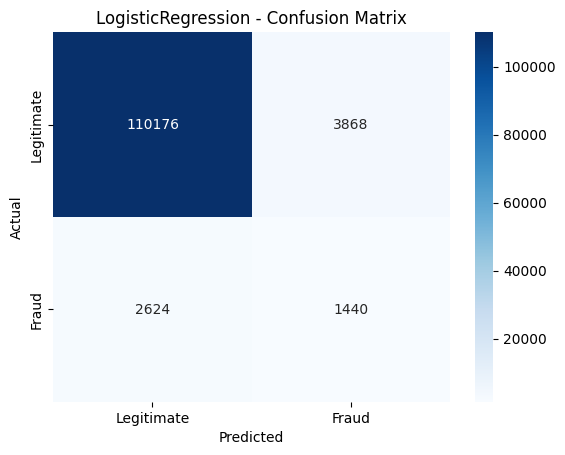

In [35]:
# Predict probabilities for test data
test_pred_probs = log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate final model
evaluate_model("LogisticRegression", y_test, test_pred_probs, threshold=lr_threshold)



For Logistic Regression, setting $C=0.01$ gave the highest validation PR-AUC of 0.4387. Using the threshold of 0.8334 selected from validation, the model achieved a test PR-AUC of 0.1725 and ROC-AUC of 0.8195. The lower performance on the later test period indicates that Logistic
Regression did not generalise as well to those transactions. The test set was not used during hyperparameter tuning or threshold selection.

## 7.2. Random Forest(Bagging)

Random Forest was trained using the full unscaled feature set because tree-based models do not require feature standardisation.

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Different tree depths to test
depth_values = [10, 20, None]
best_score = -1
best_depth = None
rf_model = None

for depth in depth_values:
    rf = RandomForestClassifier(max_depth=depth, n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)

    # Train the model
    rf.fit(X_train_full, y_train)

    # Validation probabilities
    val_pred_probs = rf.predict_proba(X_valid_full)[:, 1]

    # Validate PR-AUC
    score = average_precision_score(y_valid, val_pred_probs)
    print(f"Validation PR-AUC for max_depth={depth}: {score:.4f}")

    if score > best_score:
        best_score = score
        best_depth = depth
        rf_model = rf

print(f"Best max_depth: {best_depth} with Validation PR-AUC: {best_score:.4f}")

Validation PR-AUC for max_depth=10: 0.4869
Validation PR-AUC for max_depth=20: 0.4685
Validation PR-AUC for max_depth=None: 0.5515
Best max_depth: None with Validation PR-AUC: 0.5515


In [37]:
# Save validation probabilities
val_probs["RandomForest"] = rf_model.predict_proba(X_valid_full)[:, 1]

# Find best threshold using validation data
rf_threshold = find_best_threshold(y_valid, val_probs["RandomForest"])
print("Best threshold:", round(rf_threshold, 4))

Best F1-score: 0.5553
Best threshold: 0.18


RandomForest
  Threshold: 0.18
Accuracy : 0.969
Precision : 0.5702
Recall : 0.4048
F1 : 0.4734
ROC-AUC : 0.8607
PR-AUC : 0.4573
Confusion Matrix:
[[112804   1240]
 [  2419   1645]]


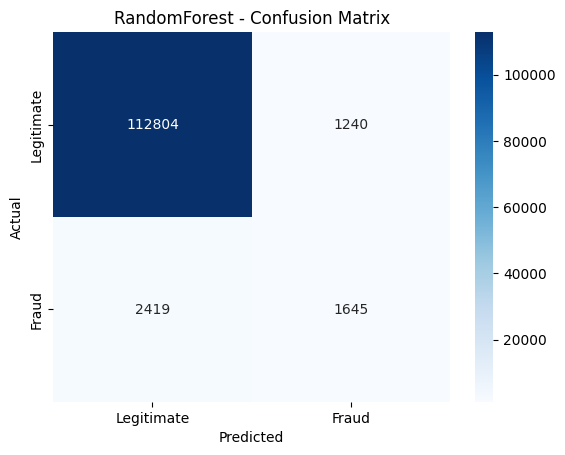

In [38]:
# Predict on test set
test_pred_probs = rf_model.predict_proba(X_test_full)[:, 1]

# Evaluate test set
evaluate_model("RandomForest", y_test, test_pred_probs, threshold=rf_threshold)

For Random Forest, max_depth=None produced the highest validation PR-AUC of 0.5515. Using the validation-selected threshold of 0.18, the model achieved a test PR-AUC of 0.4573 and ROC-AUC of 0.8607, with precision of 0.5702, recall of 0.4048 and F1-score of 0.4734.

Random Forest substantially outperformed Logistic Regression on PR-AUC and precision, suggesting that it captured the fraud patterns more effectively in this experiment.

## 7.3. XGBoost(Boosting)

In [39]:
from xgboost import XGBClassifier

# Class imbalance ratio from training data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

depth_values = [3, 6, 10]

best_score = -1
best_depth = None
xgb_model = None

for depth in depth_values:

    model = XGBClassifier(max_depth=depth, n_estimators=200, learning_rate=0.05, scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss", n_jobs=-1)
    model.fit(X_train_full, y_train)

    # Validation probabilities
    val_pred_probs = model.predict_proba(X_valid_full)[:, 1]

    # Validation PR-AUC
    score = average_precision_score(y_valid, val_pred_probs)
    print(f"Validation PR-AUC for max_depth={depth}: {score:.4f}")

    if score > best_score:
        best_score = score
        best_depth = depth
        xgb_model = model

    print(f"Best Validation PR-AUC: {best_score:.4f} (max_depth={best_depth})")


Validation PR-AUC for max_depth=3: 0.5117
Best Validation PR-AUC: 0.5117 (max_depth=3)
Validation PR-AUC for max_depth=6: 0.5442
Best Validation PR-AUC: 0.5442 (max_depth=6)
Validation PR-AUC for max_depth=10: 0.5389
Best Validation PR-AUC: 0.5442 (max_depth=6)


In [40]:
val_probs["XGBoost"] = xgb_model.predict_proba(X_valid_full)[:, 1]

xgb_threshold = find_best_threshold(y_valid, val_probs["XGBoost"])
print("Best threshold:", round(xgb_threshold, 4))

Best F1-score: 0.5363
Best threshold: 0.7797


XGBoost
  Threshold: 0.7797
Accuracy : 0.9637
Precision : 0.4695
Recall : 0.4274
F1 : 0.4474
ROC-AUC : 0.8792
PR-AUC : 0.4599
Confusion Matrix:
[[112081   1963]
 [  2327   1737]]


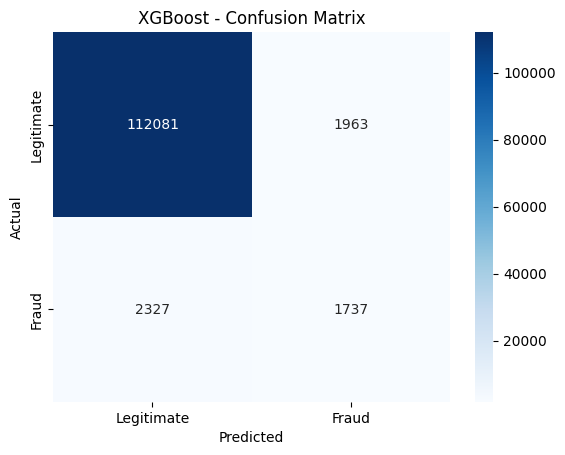

In [41]:
test_pred_probs=xgb_model.predict_proba(X_test_full)[:, 1]

evaluate_model("XGBoost", y_test, test_pred_probs, threshold=xgb_threshold)

In [42]:
print("Selected max_depth:", xgb_model.max_depth)
print("Number of trees:", xgb_model.n_estimators)
print("Learning rate:", xgb_model.learning_rate)

Selected max_depth: 6
Number of trees: 200
Learning rate: 0.05


For XGBoost, setting the max tree depth to 6 gave the best validation PR-AUC of 0.5442. When tested with a threshold of 0.7797, it scored 0.4599 in PR-AUC and 0.8792 in ROC-AUC. XGBoost scored slightly higher in PR-AUC and recall than Random Forest, but Random Forest performed better in precision and F1-score. This indicates a trade-off: XGBoost achieved slightly higher PR-AUC and recall, whereas Random Forest achieved higher precision and F1-score.

## 7.4. CatBoost

CatBoost was trained using the same frequency-encoded numerical feature representation as Random Forest and XGBoost. Therefore, CatBoost's native handling of categorical variables was not used in this experiment, which helped maintain a consistent input representation across the tree-based models.

In [43]:
from catboost import CatBoostClassifier

depth_values = [4, 8, 12]

best_score = -1
best_depth = None
cb_model = None

for depth in depth_values:

    cat_boost = CatBoostClassifier(depth=depth, iterations=200, auto_class_weights="Balanced", learning_rate=0.05, random_seed=42, verbose=0)

    # Train model
    cat_boost.fit(X_train_full, y_train)

    # Validation probabilities
    val_pred_probs = cat_boost.predict_proba(X_valid_full)[:, 1]

    # Validation PR-AUC
    score=average_precision_score(y_valid, val_pred_probs)
    print(f"Validation PR-AUC for depth={depth}: {score:.4f}")

    if score > best_score:
        best_score = score
        best_depth = depth
        cb_model = cat_boost

    print(f"Best Validation PR-AUC: {best_score:.4f} (depth={best_depth})")


Validation PR-AUC for depth=4: 0.5069
Best Validation PR-AUC: 0.5069 (depth=4)
Validation PR-AUC for depth=8: 0.5405
Best Validation PR-AUC: 0.5405 (depth=8)
Validation PR-AUC for depth=12: 0.5558
Best Validation PR-AUC: 0.5558 (depth=12)


In [44]:
val_probs["CatBoost"] = cb_model.predict_proba(X_valid_full)[:, 1]
cb_threshold = find_best_threshold(y_valid, val_probs["CatBoost"])

print("Best threshold:", round(cb_threshold, 4))

Best F1-score: 0.5443
Best threshold: 0.7463


CatBoost
  Threshold: 0.7463
Accuracy : 0.9666
Precision : 0.5179
Recall : 0.4085
F1 : 0.4567
ROC-AUC : 0.8779
PR-AUC : 0.4609
Confusion Matrix:
[[112499   1545]
 [  2404   1660]]


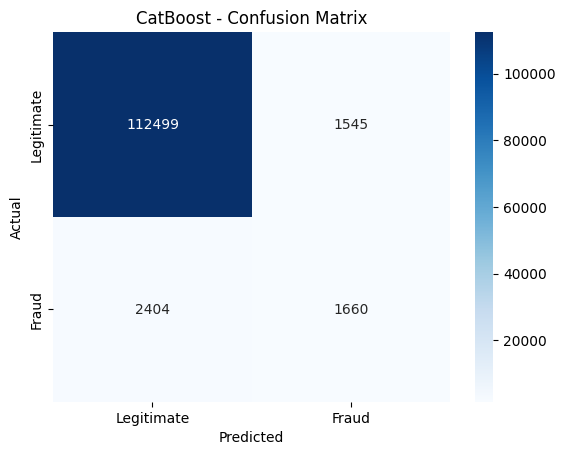

In [45]:
test_pred_probs = cb_model.predict_proba(X_test_full)[:, 1]

evaluate_model("CatBoost", y_test, test_pred_probs, threshold=cb_threshold)

In [46]:
print("Selected depth:", cb_model.get_param("depth"))
print("Iterations:", cb_model.get_param("iterations"))
print("Learning rate:", cb_model.get_param("learning_rate"))

Selected depth: 12
Iterations: 200
Learning rate: 0.05


For CatBoost, depth=12 produced the highest validation PR-AUC of 0.5558. Using the validation-selected threshold of 0.7463, it achieved a test PR-AUC of 0.4609 and ROC-AUC of 0.8779. CatBoost achieved the highest recall among the individual models evaluated at this stage, while Random Forest achieved higher precision and F1-score and XGBoost achieved slightly higher PR-AUC and ROC-AUC.

## 7.5. MLP (Neural Network, Supervised)

The MLP was trained and evaluated using the reduced, standardised feature set.

In [47]:
from sklearn.neural_network import MLPClassifier

hidden_layers = [(64,), (64, 32), (128, 64)]

best_score = -1
best_layers = None
mlp_model = None

for layers in hidden_layers:
    mlp = MLPClassifier(hidden_layer_sizes=layers, activation='relu', solver = 'adam', learning_rate_init=0.001, max_iter=50, random_state=42,
                         validation_fraction=0.1, early_stopping=True, n_iter_no_change=10, verbose=False)

    # Train model
    mlp.fit(X_train_scaled, y_train)

    # Validation probabilities
    val_pred_probs = mlp.predict_proba(X_valid_scaled)[:, 1]

    # Validation PR-AUC
    score = average_precision_score(y_valid, val_pred_probs)
    print(f"Validation PR-AUC for layers={layers}: {score:.4f}")

    if score > best_score:
        best_score = score
        best_layers = layers
        mlp_model = mlp

    print(f"Best Validation PR-AUC: {best_score:.4f} (layers={best_layers})")


Validation PR-AUC for layers=(64,): 0.4599
Best Validation PR-AUC: 0.4599 (layers=(64,))
Validation PR-AUC for layers=(64, 32): 0.4392
Best Validation PR-AUC: 0.4599 (layers=(64,))
Validation PR-AUC for layers=(128, 64): 0.4338
Best Validation PR-AUC: 0.4599 (layers=(64,))


In [48]:
val_probs["MLP"] = mlp_model.predict_proba(X_valid_scaled)[:, 1]

mlp_threshold = find_best_threshold(y_valid, val_probs["MLP"])
print("Best threshold:", round(mlp_threshold, 4))

Best F1-score: 0.4771
Best threshold: 0.266


MLP
  Threshold: 0.266
Accuracy : 0.961
Precision : 0.4154
Recall : 0.3312
F1 : 0.3686
ROC-AUC : 0.7809
PR-AUC : 0.2806
Confusion Matrix:
[[112150   1894]
 [  2718   1346]]


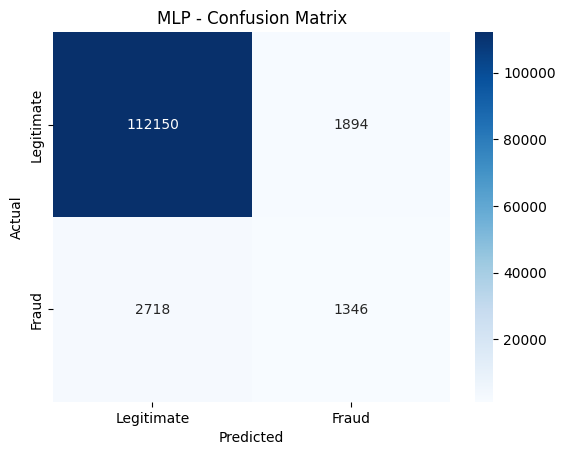

In [49]:
test_pred_probs = mlp_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("MLP", y_test, test_pred_probs, threshold=mlp_threshold)

In [50]:
print("Selected hidden layers:", mlp_model.hidden_layer_sizes)
print("Iterations used:", mlp_model.n_iter_)

Selected hidden layers: (64,)
Iterations used: 36


For the MLP model, using a single hidden layer with 64 neurons gave us the best validation PR-AUC of 0.4599. When evaluated on the test set with a 0.2660 threshold, it achieved a PR-AUC of 0.2806 and ROC-AUC of 0.7809. The MLP achieved higher PR-AUC and F1-score than Logistic Regression, but the tree-based models, including Random Forest and XGBoost, performed substantially better in this experiment.

## 7.6. Isolation Forest (Classical Anomaly Detection)

In [51]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=200, contamination="auto", random_state=42, n_jobs=-1)

# Unsupervised training - no y_train
iso_forest.fit(X_train_reduced)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [52]:
# Higher score = more anomalous / more likely fraud
train_iso_scores = -iso_forest.score_samples(X_train_reduced)
valid_iso_scores = -iso_forest.score_samples(X_valid_reduced)
test_iso_scores = -iso_forest.score_samples(X_test_reduced)

In [53]:
from sklearn.preprocessing import MinMaxScaler

iso_scaler = MinMaxScaler()
train_iso_probs = iso_scaler.fit_transform(train_iso_scores.reshape(-1, 1)).ravel()
valid_iso_probs = iso_scaler.transform(valid_iso_scores.reshape(-1, 1)).ravel()
test_iso_probs = iso_scaler.transform(test_iso_scores.reshape(-1, 1)).ravel()


In [54]:
iso_val_pr_auc = average_precision_score(y_valid, valid_iso_probs)
print("Validation PR-AUC:", round(iso_val_pr_auc, 4))

Validation PR-AUC: 0.2023


In [55]:
val_probs["IsolationForest"] = valid_iso_probs

iso_threshold = find_best_threshold(y_valid, val_probs["IsolationForest"])
print("Best threshold:", round(iso_threshold, 4))

Best F1-score: 0.2819
Best threshold: 0.312


IsolationForest
  Threshold: 0.312
Accuracy : 0.9209
Precision : 0.1693
Recall : 0.3322
F1 : 0.2243
ROC-AUC : 0.7699
PR-AUC : 0.1155
Confusion Matrix:
[[107421   6623]
 [  2714   1350]]


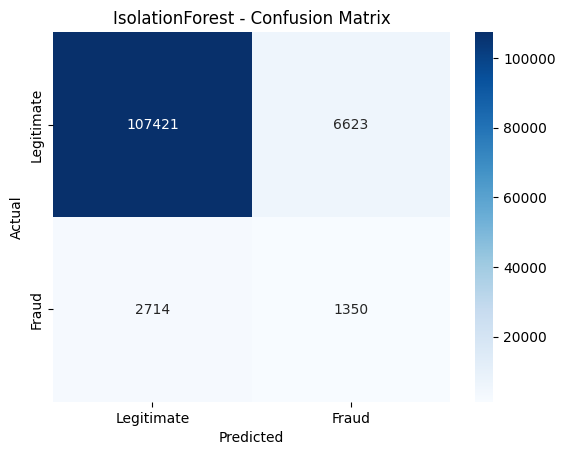

In [56]:
evaluate_model("IsolationForest", y_test, test_iso_probs, threshold=iso_threshold)

Isolation Forest was trained without fraud labels and therefore served
as an unsupervised anomaly-detection baseline. It achieved a validation
PR-AUC of 0.2023. Using the validation-selected threshold of 0.3120, it
achieved a test PR-AUC of 0.1155 and ROC-AUC of 0.7699.

Its performance was substantially below the supervised models,
particularly in precision and PR-AUC. In this experiment, anomaly score
alone was therefore less effective at separating fraudulent and
legitimate transactions than models trained using labelled examples.

## 7.7. Autoencoder (Deep Anomaly Detection)

In [57]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(42)

# Train only on legitimate transactions
X_train_normal = X_train_scaled[y_train.values == 0 ]
n_features = X_train_normal.shape[1]

# Autoencoder
inputs = layers.Input(shape=(n_features,))
encoded = layers.Dense(128, activation="relu")(inputs)
encoded = layers.Dense(32, activation="relu")(encoded)
decoded = layers.Dense(128, activation="relu")(encoded)
outputs = layers.Dense(n_features, activation="linear")(decoded)

autoencoder = models.Model(inputs, outputs)

autoencoder.compile(optimizer="adam",loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = autoencoder.fit(X_train_normal, X_train_normal, epochs=30, batch_size=1024, validation_split=0.1, callbacks=[early_stop], verbose=0)

print("Epochs used:", len(history.history["loss"]))

Epochs used: 30


In [58]:
def reconstruction_error(model, X):
    reconstructed = model.predict(X, verbose=0)
    return np.mean((X - reconstructed) ** 2, axis=1)

train_ae_scores = reconstruction_error(autoencoder, X_train_scaled)
valid_ae_scores = reconstruction_error(autoencoder, X_valid_scaled)
test_ae_scores = reconstruction_error(autoencoder, X_test_scaled)

In [59]:
from sklearn.preprocessing import MinMaxScaler

ae_scaler = MinMaxScaler()
ae_scaler.fit(train_ae_scores.reshape(-1, 1))

valid_ae_probs = ae_scaler.transform(valid_ae_scores.reshape(-1, 1)).ravel()
test_ae_probs = ae_scaler.transform(test_ae_scores.reshape(-1, 1)).ravel()

In [60]:
ae_val_pr_auc = average_precision_score(y_valid, valid_ae_probs)
print("Validation PR-AUC:", round(ae_val_pr_auc, 4))

Validation PR-AUC: 0.2137


In [61]:
val_probs["Autoencoder"] = valid_ae_probs

ae_threshold = find_best_threshold(y_valid, val_probs["Autoencoder"])
print("Best threshold:", round(ae_threshold, 4))

Best F1-score: 0.3123
Best threshold: 0.0002


Autoencoder
  Threshold: 0.0002
Accuracy : 0.9238
Precision : 0.1754
Recall : 0.3282
F1 : 0.2286
ROC-AUC : 0.7513
PR-AUC : 0.109
Confusion Matrix:
[[107773   6271]
 [  2730   1334]]


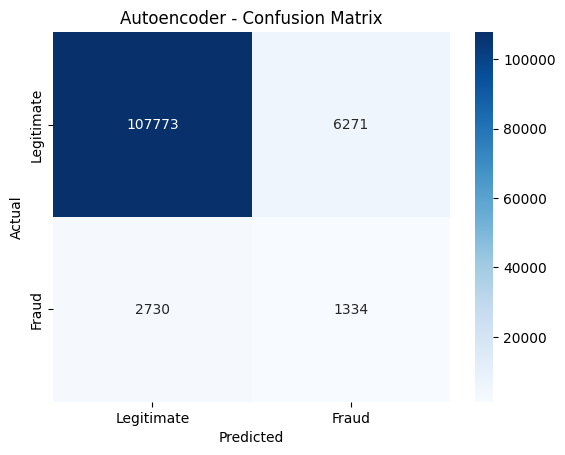

In [62]:
evaluate_model("Autoencoder", y_test, test_ae_probs, threshold=ae_threshold)

The Autoencoder was trained using only legitimate training transactions so that it could learn their reconstruction patterns. Because class labels were used to select the legitimate training subset, this model is more accurately described as a one-class or semi-supervised anomaly detector rather than a fully unsupervised model.

The model achieved a validation PR-AUC of 0.2137. Using the validation-selected threshold of 0.0002, it achieved a test PR-AUC of 0.109 and ROC-AUC of 0.7513

The Autoencoder performed below Isolation Forest and substantially below the supervised tree-based models. In this experiment, reconstruction error alone provided limited separation between fraudulent and legitimate transactions.

# 8. Soft Voting(Ensemble)



In [63]:
# 5 Supervised Models included in Soft Voting
voting_models = ["LogisticRegression", "RandomForest", "XGBoost", "CatBoost", "MLP"]

# Average validation probabilities
soft_voting_val_probs = np.mean([val_probs[m] for m in voting_models], axis=0)
val_probs["SoftVoting"] = soft_voting_val_probs

# Validation PR-AUC
soft_voting_val_pr_auc = average_precision_score(y_valid, soft_voting_val_probs)
print("Validation PR-AUC:", round(soft_voting_val_pr_auc, 4))

# Select threshold using validation data
soft_voting_threshold = find_best_threshold( y_valid, soft_voting_val_probs)
print("Best threshold:", round(soft_voting_threshold, 4))

Validation PR-AUC: 0.5745
Best F1-score: 0.5631
Best threshold: 0.5063


SoftVoting
  Threshold: 0.5063
Accuracy : 0.9662
Precision : 0.5102
Recall : 0.4139
F1 : 0.457
ROC-AUC : 0.8829
PR-AUC : 0.4652
Confusion Matrix:
[[112429   1615]
 [  2382   1682]]


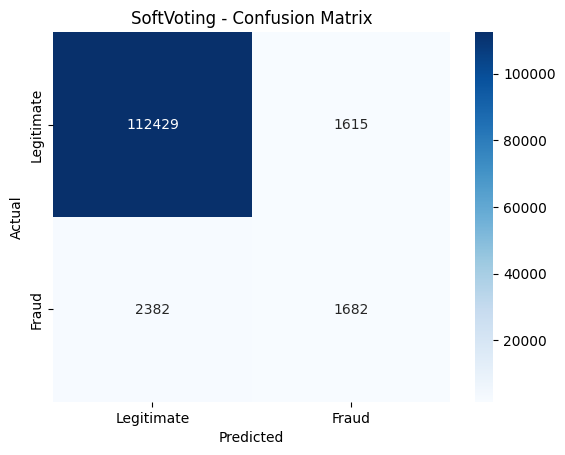

In [64]:
# Average test probabilities
soft_voting_test_probs = np.mean( [test_probs[m] for m in voting_models], axis=0)
evaluate_model( "SoftVoting", y_test, soft_voting_test_probs, threshold=soft_voting_threshold)

Soft Voting combined the predicted probabilities from Logistic Regression, Random Forest, XGBoost, CatBoost and MLP using equal weights. It achieved a validation PR-AUC of 0.5745

Using the validation-selected threshold of  0.5063, the ensemble achieved a test PR-AUC of 0.4652 and ROC-AUC of 0.8829. Although its ROC-AUC was higher than that of the individual models evaluated at this stage, its test PR-AUC and F1-score did not exceed the strongest individual models. Therefore, equal-weight probability averaging did not provide a clear improvement over the best individual classifiers.

# 9. Stacking

Stacking combines the predictions of the five supervised base models: Logistic Regression, Random Forest, XGBoost, CatBoost and MLP.

The predicted fraud probabilities from these models were used as inputs to a Logistic Regression meta-model.

To reduce leakage, the validation period was divided chronologically into two halves. The first half was used to train the meta-model, while the
second half was used to select the decision threshold. The test set remained unseen until final evaluation.

In [65]:
from sklearn.linear_model import LogisticRegression

# Base models included in stacking
stacking_models = [ "LogisticRegression", "RandomForest", "XGBoost", "CatBoost", "MLP" ]

# Each column contains probabilities from one base model
meta_features_val = np.column_stack([val_probs[m] for m in stacking_models])
meta_features_test = np.column_stack([test_probs[m] for m in stacking_models])

print("Validation meta-feature shape:", meta_features_val.shape)
print("Test meta-feature shape:", meta_features_test.shape)

Validation meta-feature shape: (118108, 5)
Test meta-feature shape: (118108, 5)


In [66]:
# Convert labels to NumPy array
y_valid_array = np.asarray(y_valid)

# Middle point of validation period
split_point = len(y_valid_array) // 2

# First half - train meta-model
X_meta_train = meta_features_val[:split_point]
y_meta_train = y_valid_array[:split_point]

# Second half - select threshold
X_meta_threshold = meta_features_val[split_point:]
y_meta_threshold = y_valid_array[split_point:]

print("Meta-model training rows:", len(y_meta_train))
print("Threshold selection rows:", len(y_meta_threshold))

Meta-model training rows: 59054
Threshold selection rows: 59054


In [67]:
meta_model = LogisticRegression(max_iter=300, random_state=42)
meta_model.fit(X_meta_train, y_meta_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [68]:
stacking_threshold_probs = meta_model.predict_proba(X_meta_threshold)[:, 1]
stacking_val_pr_auc = average_precision_score(y_meta_threshold, stacking_threshold_probs)
print("Validation PR-AUC:", round(stacking_val_pr_auc, 4))

Validation PR-AUC: 0.5485


In [69]:
stacking_threshold = find_best_threshold(y_meta_threshold, stacking_threshold_probs)
print("Best threshold:", round(stacking_threshold, 4))

Best F1-score: 0.55
Best threshold: 0.2656


Stacking
  Threshold: 0.2656
Accuracy : 0.9659
Precision : 0.5049
Recall : 0.4225
F1 : 0.46
ROC-AUC : 0.89
PR-AUC : 0.4847
Confusion Matrix:
[[112360   1684]
 [  2347   1717]]


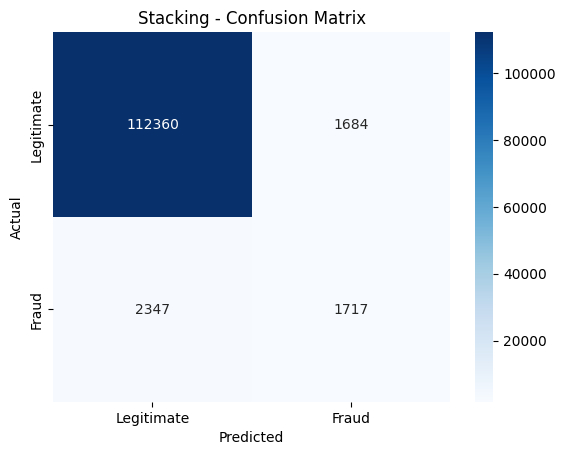

In [70]:
stacking_test_probs = meta_model.predict_proba(meta_features_test)[:, 1]
evaluate_model("Stacking", y_test, stacking_test_probs, threshold=stacking_threshold)

In [71]:
test_probs["Stacking"] = stacking_test_probs
stacking_clean_val_probs = stacking_threshold_probs
stacking_clean_y_valid = y_meta_threshold


In [72]:
print("Meta-model coefficients:")

for model_name, coefficient in zip(stacking_models, meta_model.coef_[0]):
    print(model_name, ":", round(coefficient, 4))

Meta-model coefficients:
LogisticRegression : 0.6123
RandomForest : 3.5543
XGBoost : 2.8115
CatBoost : 2.3414
MLP : 0.663


The meta-model achieved a PR-AUC of 0.5485 on the second validation half. Using the selected threshold of 0.2656, Stacking achieved a test PR-AUC of 0.4847 and ROC-AUC of 0.89, which were the highest observed values among the evaluated models. This suggests that combining the supervised base-model predictions through stacking improved ranking performance in this experiment.

Because the base-model hyperparameters had already been selected using the full validation set, this represents a pragmatic split-validation stacking approach rather than fully out-of-fold stacking. Fully out-of-fold predictions would provide a stricter stacking procedure and are noted as a possible methodological improvement.

# 10. Model Comparison

All models were compared on the same unseen chronological test set. Because the dataset is highly imbalanced, PR-AUC was treated as the primary performance metric. ROC-AUC, precision, recall, F1-score and accuracy were also reported.

The comparison includes supervised models, anomaly-based models and ensemble models.

10.1 Final results table

In [73]:
from sklearn.metrics import average_precision_score

comparison_rows = []

# Helper function
def add_pr_auc_result(model_name, y_train_true, train_prob,
                      y_valid_true, valid_prob,
                      y_test_true, test_prob):

    comparison_rows.append({
        "Model": model_name,
        "Train PR-AUC": average_precision_score(y_train_true, train_prob),
        "Validation PR-AUC": average_precision_score(y_valid_true, valid_prob),
        "Test PR-AUC": average_precision_score(y_test_true, test_prob)
    })


# 1. Logistic Regression
lr_train_probs = log_reg_model.predict_proba(X_train_scaled)[:, 1]
lr_valid_probs = log_reg_model.predict_proba(X_valid_scaled)[:, 1]
lr_test_probs = log_reg_model.predict_proba(X_test_scaled)[:, 1]

add_pr_auc_result(
    "Logistic Regression",
    y_train, lr_train_probs,
    y_valid, lr_valid_probs,
    y_test, lr_test_probs
)

# 2. Random Forest
rf_train_probs = rf_model.predict_proba(X_train_full)[:, 1]
rf_valid_probs = rf_model.predict_proba(X_valid_full)[:, 1]
rf_test_probs = rf_model.predict_proba(X_test_full)[:, 1]

add_pr_auc_result(
    "Random Forest",
    y_train, rf_train_probs,
    y_valid, rf_valid_probs,
    y_test, rf_test_probs
)

# 3. XGBoost
xgb_train_probs = xgb_model.predict_proba(X_train_full)[:, 1]
xgb_valid_probs = xgb_model.predict_proba(X_valid_full)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test_full)[:, 1]

add_pr_auc_result(
    "XGBoost",
    y_train, xgb_train_probs,
    y_valid, xgb_valid_probs,
    y_test, xgb_test_probs
)

# 4. CatBoost
cb_train_probs = cb_model.predict_proba(X_train_full)[:, 1]
cb_valid_probs = cb_model.predict_proba(X_valid_full)[:, 1]
cb_test_probs = cb_model.predict_proba(X_test_full)[:, 1]

add_pr_auc_result(
    "CatBoost",
    y_train, cb_train_probs,
    y_valid, cb_valid_probs,
    y_test, cb_test_probs
)

# 5. MLP
mlp_train_probs = mlp_model.predict_proba(X_train_scaled)[:, 1]
mlp_valid_probs = mlp_model.predict_proba(X_valid_scaled)[:, 1]
mlp_test_probs = mlp_model.predict_proba(X_test_scaled)[:, 1]

add_pr_auc_result(
    "MLP",
    y_train, mlp_train_probs,
    y_valid, mlp_valid_probs,
    y_test, mlp_test_probs
)


# 6. Isolation Forest
add_pr_auc_result(
    "Isolation Forest",
    y_train, train_iso_probs,
    y_valid, valid_iso_probs,
    y_test, test_iso_probs
)

# 7. Autoencoder
# Convert training reconstruction errors using the same scaler already fitted on the training reconstruction errors
train_ae_probs = ae_scaler.transform(
    train_ae_scores.reshape(-1, 1)
).ravel()

add_pr_auc_result(
    "Autoencoder",
    y_train, train_ae_probs,
    y_valid, valid_ae_probs,
    y_test, test_ae_probs
)

# 8. Soft Voting
# Average probabilities of the five supervised models
soft_train_probs = np.mean([
    lr_train_probs,
    rf_train_probs,
    xgb_train_probs,
    cb_train_probs,
    mlp_train_probs
], axis=0)

soft_valid_probs = np.mean([
    lr_valid_probs,
    rf_valid_probs,
    xgb_valid_probs,
    cb_valid_probs,
    mlp_valid_probs
], axis=0)

soft_test_probs = np.mean([
    lr_test_probs,
    rf_test_probs,
    xgb_test_probs,
    cb_test_probs,
    mlp_test_probs
], axis=0)

add_pr_auc_result(
    "Soft Voting",
    y_train, soft_train_probs,
    y_valid, soft_valid_probs,
    y_test, soft_test_probs
)

# Create comparison table for first 8 models
pr_auc_comparison = pd.DataFrame(comparison_rows)

display(
    pr_auc_comparison
    .set_index("Model")
    .round(4)
)

,Train PR-AUC,Validation PR-AUC,Test PR-AUC
Model,,,
Logistic Regression,0.4318,0.4387,0.1725
Random Forest,1.0000,0.5515,0.4573
XGBoost,0.6777,0.5442,0.4599
CatBoost,0.7910,0.5558,0.4609
MLP,0.7491,0.4599,0.2806
Isolation Forest,0.1419,0.2023,0.1155
Autoencoder,0.2104,0.2137,0.1090
Soft Voting,0.8720,0.5745,0.4652


In [74]:
# 9. Stacking
# Performance on the data used to train the meta-model
stacking_meta_train_probs = meta_model.predict_proba(
    X_meta_train
)[:, 1]

stacking_meta_train_pr_auc = average_precision_score(
    y_meta_train,
    stacking_meta_train_probs
)

# Performance on second validation half
stacking_validation_pr_auc = average_precision_score(
    y_meta_threshold,
    stacking_threshold_probs
)

# Performance on untouched test set
stacking_test_pr_auc = average_precision_score(
    y_test,
    stacking_test_probs
)

stacking_comparison = pd.DataFrame({
    "Dataset": [
        "Meta-model Training",
        "Validation (Second Half)",
        "Test"
    ],
    "PR-AUC": [
        stacking_meta_train_pr_auc,
        stacking_validation_pr_auc,
        stacking_test_pr_auc
    ]
})

display(stacking_comparison.round(4))

,Dataset,PR-AUC
0,Meta-model Training,0.6050
1,Validation (Second Half),0.5485
2,Test,0.4847


In [75]:
stacking_row = pd.DataFrame({
    "Model": ["Stacking"],
    "Train PR-AUC": [stacking_meta_train_pr_auc],
    "Validation PR-AUC": [stacking_validation_pr_auc],
    "Test PR-AUC": [stacking_test_pr_auc]
})

all_models_pr_auc = pd.concat(
    [pr_auc_comparison, stacking_row],
    ignore_index=True
)

display(
    all_models_pr_auc
    .set_index("Model")
    .round(4)
)

,Train PR-AUC,Validation PR-AUC,Test PR-AUC
Model,,,
Logistic Regression,0.4318,0.4387,0.1725
Random Forest,1.0000,0.5515,0.4573
XGBoost,0.6777,0.5442,0.4599
CatBoost,0.7910,0.5558,0.4609
MLP,0.7491,0.4599,0.2806
Isolation Forest,0.1419,0.2023,0.1155
Autoencoder,0.2104,0.2137,0.1090
Soft Voting,0.8720,0.5745,0.4652
Stacking,0.6050,0.5485,0.4847


For Stacking, the training value refers to the first half of the validation period used to train the meta-model, while the validation value refers to the second half used for threshold selection. Therefore, its training value is not directly equivalent to the training values reported for the base models.

In [76]:
results_table = pd.DataFrame(model_scores).T

# Add validation-selected thresholds
results_table["Threshold"] = pd.Series(model_thresholds)

# Arrange columns
results_table = results_table[[ "Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]]

# Primary metric = PR-AUC
results_table = results_table.sort_values("PR-AUC", ascending=False)
display(results_table.round(4))

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Stacking,0.2656,0.9659,0.5049,0.4225,0.4600,0.8900,0.4847
SoftVoting,0.5063,0.9662,0.5102,0.4139,0.4570,0.8829,0.4652
CatBoost,0.7463,0.9666,0.5179,0.4085,0.4567,0.8779,0.4609
XGBoost,0.7797,0.9637,0.4695,0.4274,0.4474,0.8792,0.4599
RandomForest,0.1800,0.9690,0.5702,0.4048,0.4734,0.8607,0.4573
MLP,0.2660,0.9610,0.4154,0.3312,0.3686,0.7809,0.2806
LogisticRegression,0.8334,0.9450,0.2713,0.3543,0.3073,0.8195,0.1725
IsolationForest,0.3120,0.9209,0.1693,0.3322,0.2243,0.7699,0.1155
Autoencoder,0.0002,0.9238,0.1754,0.3282,0.2286,0.7513,0.1090


10.2 PR-AUC comparison

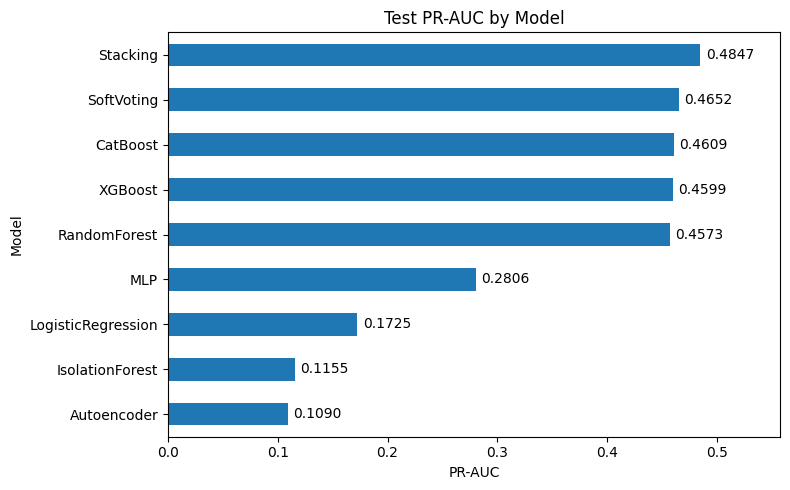

In [77]:
pr_results = results_table["PR-AUC"].sort_values()

ax = pr_results.plot(kind="barh", figsize=(8, 5))
# Add value labels to each horizontal bar
ax.bar_label(ax.containers[0], fmt="%.4f", padding=4)
ax.set_title("Test PR-AUC by Model")
ax.set_xlabel("PR-AUC")
ax.set_ylabel("Model")
ax.set_xlim(0, max(pr_results.values) * 1.15)
plt.tight_layout()
plt.show()

10.3 Precision, Recall and F1 comparison

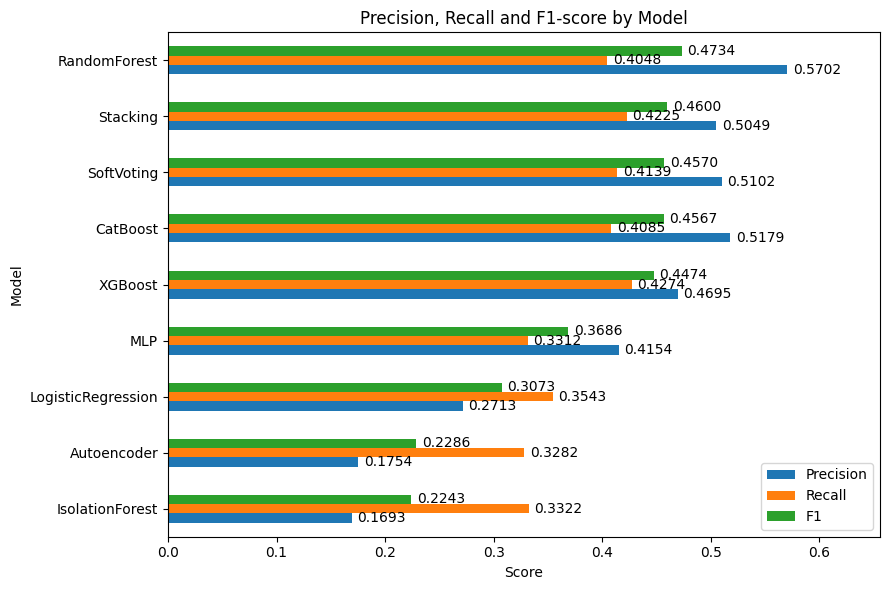

In [78]:
classification_metrics = results_table[["Precision", "Recall", "F1"]].sort_values("F1")

ax = classification_metrics.plot(kind="barh", figsize=(9, 6))
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=4)
ax.set_title("Precision, Recall and F1-score by Model")
ax.set_xlabel("Score")
ax.set_ylabel("Model")
ax.set_xlim(0, classification_metrics.values.max() * 1.15)
plt.tight_layout()
plt.show()

10.4 Precision–Recall curves

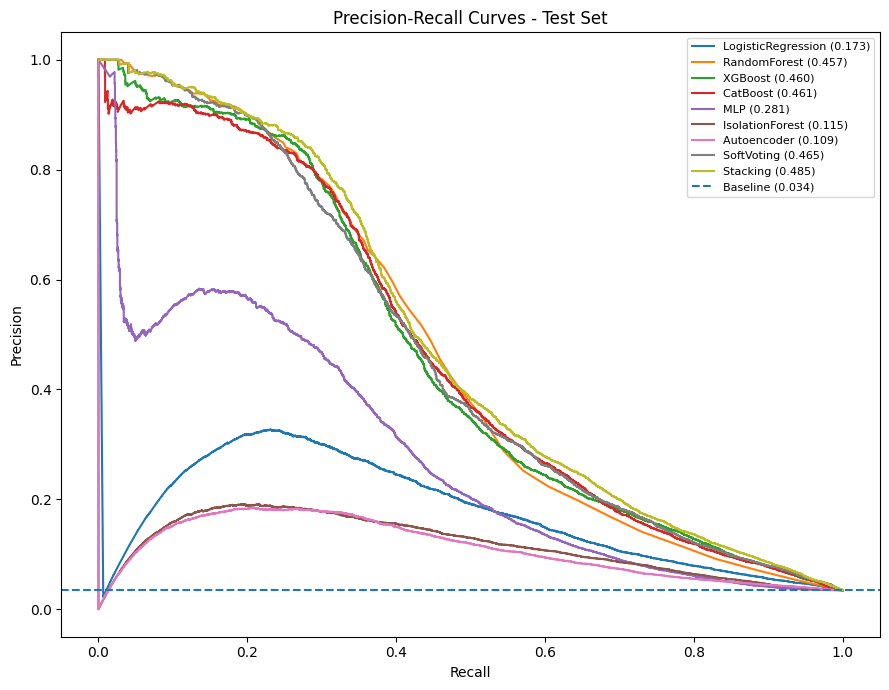

In [79]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(9, 7))

for model_name, probs in test_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = model_scores[model_name]["PR-AUC"]
    plt.plot(recall, precision, label=f"{model_name} ({pr_auc:.3f})")

# Random classifier baseline = fraud prevalence
baseline = y_test.mean()

plt.axhline(baseline, linestyle="--", label=f"Baseline ({baseline:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Test Set")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

10.5 ROC curves

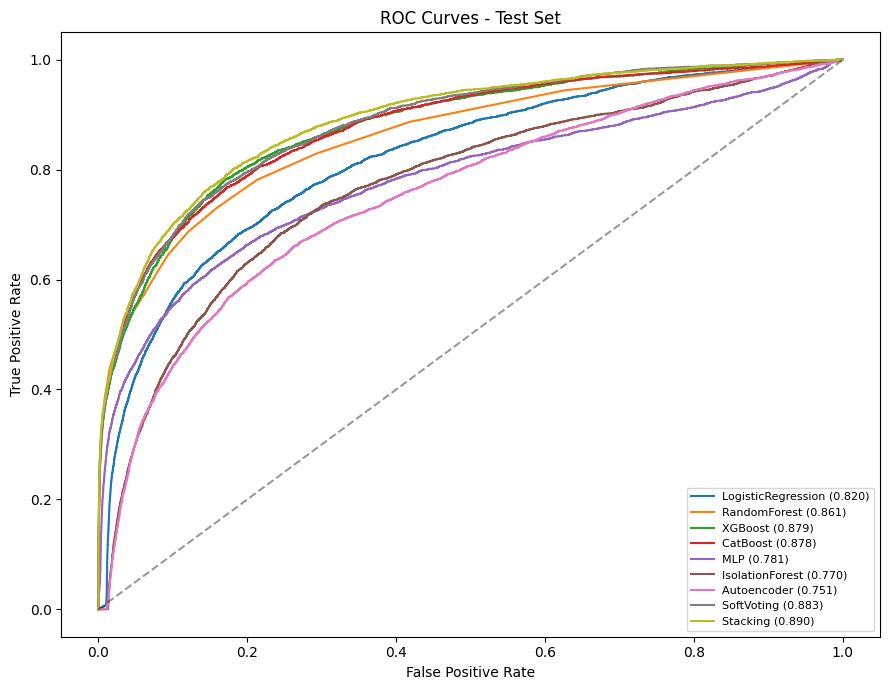

In [80]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 7))

for model_name, probs in test_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = model_scores[ model_name ]["ROC-AUC"]
    plt.plot(fpr, tpr, label=f"{model_name} ({auc_score:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

10.6 Identify the leading model

In [81]:
best_model_name = results_table["PR-AUC"].idxmax()
print("Highest observed test PR-AUC:", best_model_name)
display(results_table.loc[[best_model_name]].round(4))

Highest observed test PR-AUC: Stacking


,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Stacking,0.2656,0.9659,0.5049,0.4225,0.46,0.89,0.4847


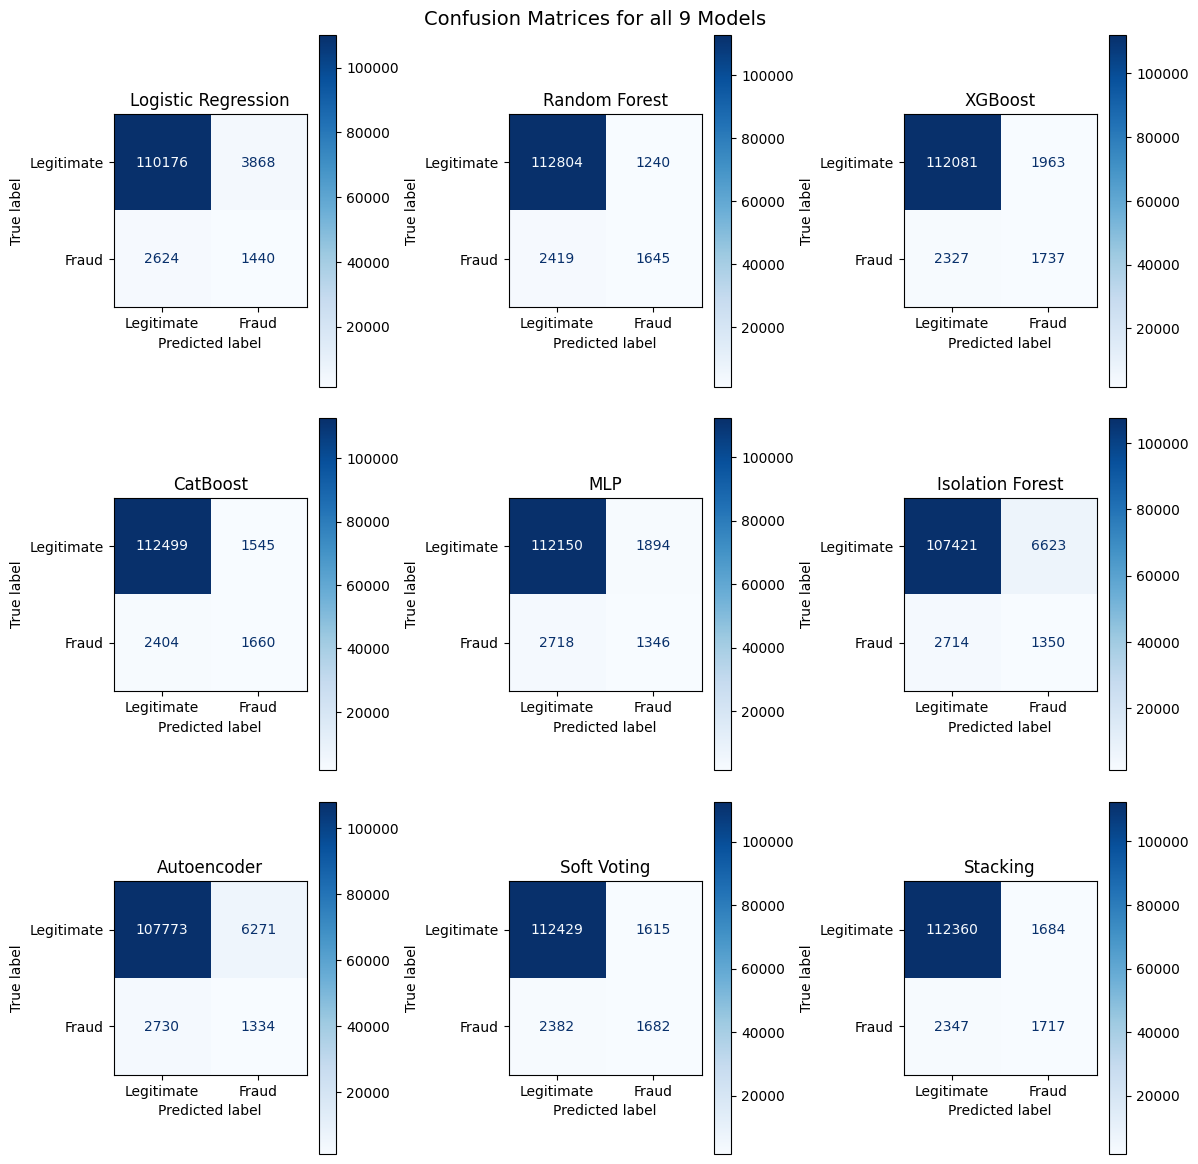

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models_to_plot = {"Logistic Regression": (test_probs["LogisticRegression"], model_thresholds["LogisticRegression"]), "Random Forest": (test_probs["RandomForest"], model_thresholds["RandomForest"]), 
                  "XGBoost": (test_probs["XGBoost"], model_thresholds["XGBoost"]), "CatBoost": (test_probs["CatBoost"], model_thresholds["CatBoost"]), "MLP": (test_probs["MLP"], model_thresholds["MLP"]),
                  "Isolation Forest": (test_probs["IsolationForest"], model_thresholds["IsolationForest"]), "Autoencoder": (test_probs["Autoencoder"], model_thresholds["Autoencoder"]), 
                  "Soft Voting": (test_probs["SoftVoting"], model_thresholds["SoftVoting"]), "Stacking": (test_probs["Stacking"], model_thresholds["Stacking"])}


fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for ax, (model_name, (probs, threshold)) in zip(axes, models_to_plot.items()):
    y_pred = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
    disp.plot(ax=ax, colorbar=True, values_format="d", cmap="Blues")
    ax.set_title(model_name)

plt.suptitle("Confusion Matrices for all 9 Models", fontsize=14)
plt.tight_layout()
plt.show()

10.7. Statistical Confidence - Bootstrap Confidence Intervals

In [83]:
def bootstrap_auc_ci(y_true, y_prob, n_bootstrap=200, seed=42):

    rng = np.random.RandomState(seed)
    roc_scores = []
    pr_scores = []

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    for _ in range(n_bootstrap):

        idx = rng.randint(
            0,
            len(y_true),
            len(y_true)
        )

        # Skip sample if it contains only one class
        if len(np.unique(y_true[idx])) < 2:
            continue

        roc_scores.append(roc_auc_score(y_true[idx], y_prob[idx]))

        pr_scores.append(average_precision_score(y_true[idx], y_prob[idx]))

    return {
        "ROC-AUC Lower": np.percentile(roc_scores, 2.5),
        "ROC-AUC Upper": np.percentile(roc_scores, 97.5),
        "PR-AUC Lower": np.percentile(pr_scores, 2.5),
        "PR-AUC Upper": np.percentile(pr_scores, 97.5)
    }

In [84]:
ci_results = {}

for model_name, probs in test_probs.items():
    ci_results[model_name] = bootstrap_auc_ci(y_test, probs, n_bootstrap=200, seed=42)

ci_df = pd.DataFrame(ci_results).T
display(ci_df.round(4))

,ROC-AUC Lower,ROC-AUC Upper,PR-AUC Lower,PR-AUC Upper
LogisticRegression,0.8120,0.8273,0.1640,0.1824
RandomForest,0.8547,0.8671,0.4423,0.4746
XGBoost,0.8735,0.8856,0.4435,0.4782
CatBoost,0.8723,0.8838,0.4441,0.4789
MLP,0.7712,0.7897,0.2665,0.2985
IsolationForest,0.7629,0.7782,0.1099,0.1224
Autoencoder,0.7438,0.7605,0.1037,0.1151
SoftVoting,0.8767,0.8891,0.4482,0.4812
Stacking,0.8839,0.8963,0.4690,0.5013


Bootstrap resampling was used to estimate 95% confidence intervals for ROC-AUC and PR-AUC. Stacking produced the highest observed PR-AUC of 0.5013, with a 95% bootstrap confidence interval of approximately 0.46911–0.0.5013.

The individual confidence intervals for Stacking, XGBoost, Random Forest and Soft Voting overlapped. Therefore, although Stacking had the highest point estimate, these intervals alone do not establish that its performance was statistically significantly better than the other leading models. 

10.8 Temporal Stability

In [85]:
# Divide test period into four chronological parts
test_time_bucket = pd.qcut(test_set["TransactionDT"], 4, labels=False)

y_test_array = np.asarray(y_test)
best_probs = np.asarray(test_probs[best_model_name])

time_results = []

for bucket in sorted(test_time_bucket.unique()):

    mask = (test_time_bucket == bucket).values

    y_bucket = y_test_array[mask]
    prob_bucket = best_probs[mask]

    time_results.append({
        "Time Period": int(bucket) + 1,
        "Transactions": len(y_bucket),
        "Fraud Rate": y_bucket.mean(),
        "PR-AUC": average_precision_score(
            y_bucket,
            prob_bucket
        ),
        "ROC-AUC": roc_auc_score(
            y_bucket,
            prob_bucket
        )
    })


time_results_df = pd.DataFrame(time_results)
display(time_results_df.round(4))

,Time Period,Transactions,Fraud Rate,PR-AUC,ROC-AUC
0,1,29527,0.0332,0.4221,0.8861
1,2,29527,0.0295,0.4819,0.8875
2,3,29527,0.0354,0.4807,0.8818
3,4,29527,0.0396,0.5415,0.9020


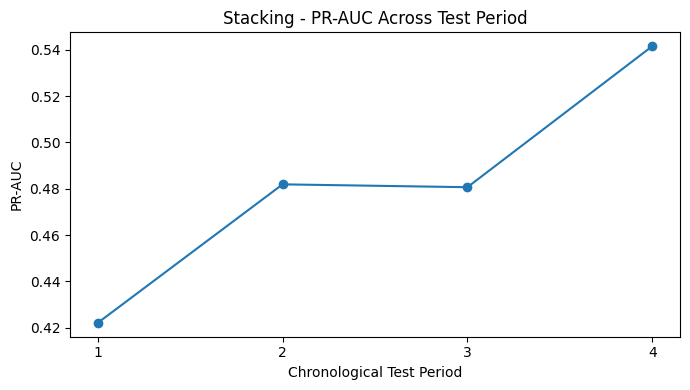

In [86]:
plt.figure(figsize=(7, 4))
plt.plot(time_results_df["Time Period"], time_results_df["PR-AUC"], marker="o")
plt.xlabel("Chronological Test Period")
plt.ylabel("PR-AUC")
plt.title(f"{best_model_name} - PR-AUC Across Test Period")
plt.xticks([1, 2, 3, 4])
plt.tight_layout()
plt.show()

The chronological test set was divided into four equally sized groups based on TransactionDT, with each group containing 29,527 transactions. Stacking maintained relatively stable ROC-AUC across the first three groups, ranging from 0.8810 to 0.8836, before increasing to 0.9018 in the final group.

PR-AUC increased from 0.4221 in the first group to 0.5415 in the final group. However, fraud prevalence also varied from 2.95% to 3.96%, which should be considered when interpreting changes in PR-AUC.

The model showed variation in performance over time, but there was no evidence of change in fraud pattern.

# 11. SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) was used to investigate how model inputs influenced fraud predictions.

Because Stacking achieved the highest observed test PR-AUC, explainability was considered at two levels:

1. XGBoost was analysed at the original feature-leve beacuse it has acheived the highest PR-AUC and it supports TreeSHAP analysis.

2. The Stacking meta-model was analysed at the base-model level  to understand how the predicted probabilities from the five base models influenced the final ensemble prediction.

The SHAP analysis was performed after model evaluation and was not used for model training, hyperparameter selection or threshold selection.

Although CatBoost acheived marginally higher PR-AUC and F1-scores, XGBoost was chosen for SHAP analysis because of its comparable predictive performnace and faster computation of SHAP values.

In [87]:
import shap

# Explain XGBoost at the original feature level
shap_model = xgb_model

# XGBoost was trained using the full unscaled feature set
X_shap_data = X_test_full

print("Model explained: XGBoost")
print("Number of features:", X_shap_data.shape[1])

Model explained: XGBoost
Number of features: 422


In [88]:
np.random.seed(42)

sample_size = min(2000, len(X_shap_data))
sample_idx = np.random.choice(len(X_shap_data), sample_size, replace=False)
X_shap_sample = X_shap_data.iloc[sample_idx]

print("SHAP sample size:", len(X_shap_sample))

SHAP sample size: 2000


In [89]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_shap_sample)
print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (2000, 422)


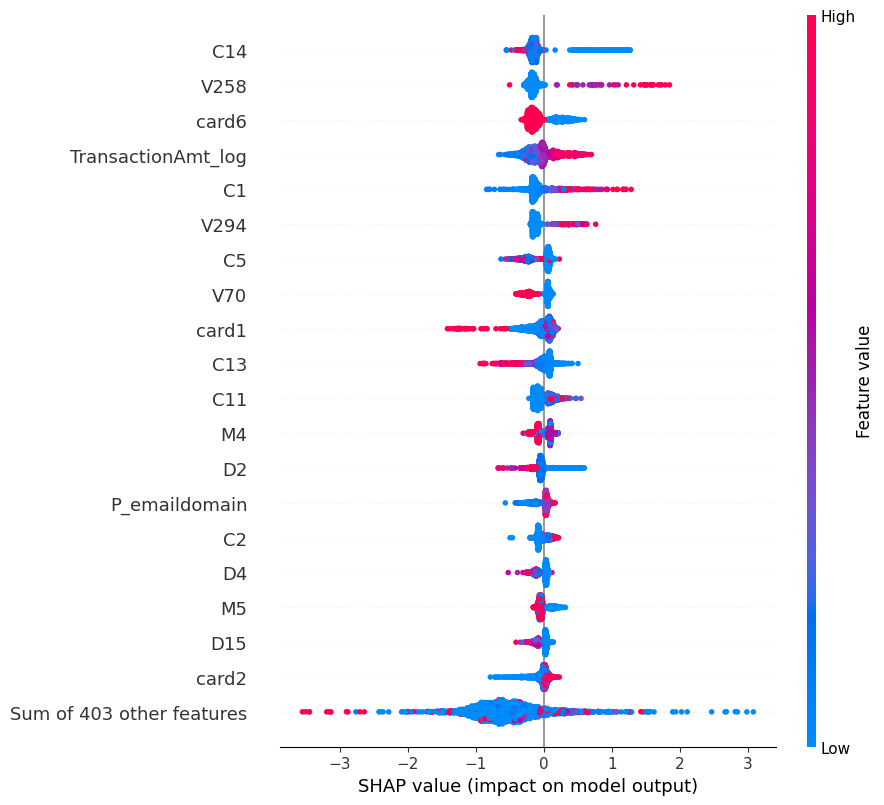

In [90]:
shap.plots.beeswarm(shap_values, max_display=20)

The SHAP beeswarm plot shows both the magnitude and direction of feature
effects. Positive SHAP values increase the XGBoost model output towards
the fraud class, while negative values decrease it towards the
legitimate class.

For this TreeSHAP analysis, SHAP values represent contributions to the
model's raw output and should not be interpreted directly as percentage
changes in fraud probability.

For frequency-encoded categorical variables, the displayed numerical
value represents the training-set frequency of the original category
rather than an inherent numerical ordering of that category.

Global Feature Importance

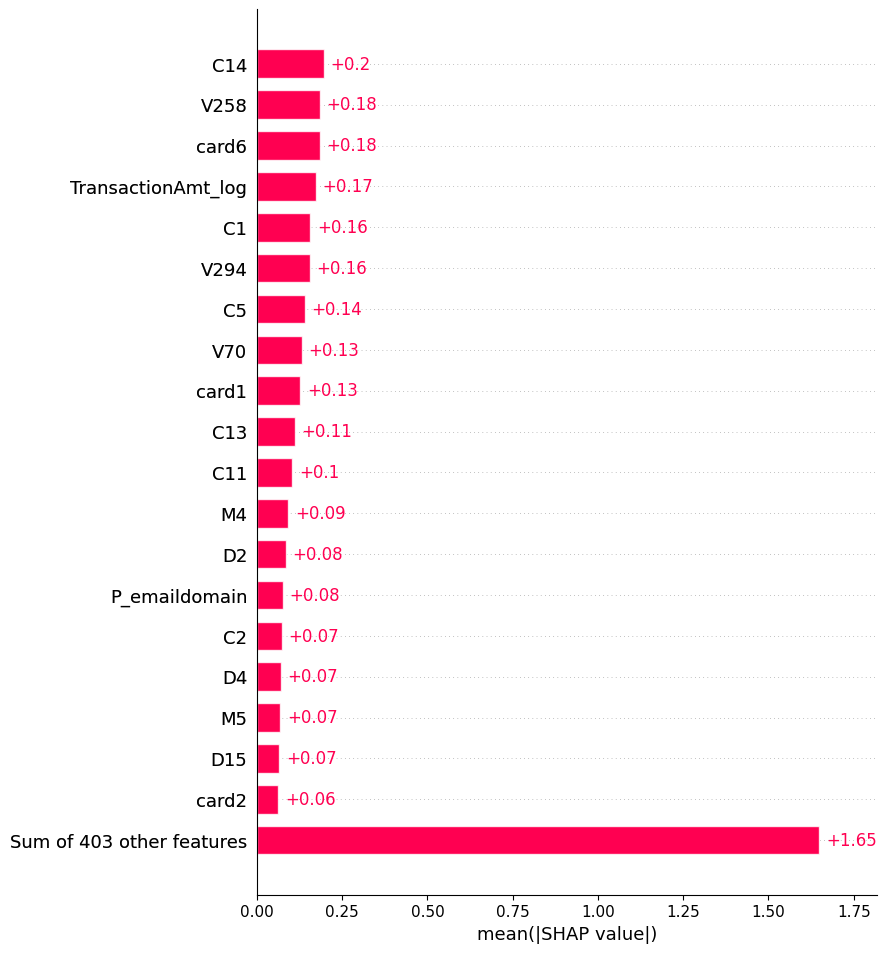

In [91]:
shap.plots.bar(shap_values, max_display=20)

The global SHAP importance plot ranks features according to their mean
absolute SHAP value. Features with larger mean absolute SHAP values had
a greater overall influence on the model's predictions. This measure
shows the strength of a feature's contribution but does not indicate
whether the feature increased or decreased fraud risk.

Get the Top Features as a Table

In [92]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({"Feature": X_shap_sample.columns, "Mean Absolute SHAP": mean_abs_shap})
shap_importance = shap_importance.sort_values("Mean Absolute SHAP", ascending=False)

display(shap_importance.head(20))

,Feature,Mean Absolute SHAP
25,C14,0.196197
306,V258,0.184177
6,card6,0.183501
419,TransactionAmt_log,0.171835
12,C1,0.156112
342,V294,0.155630
16,C5,0.140259
118,V70,0.132185
1,card1,0.126644
24,C13,0.111522


Dependence Plot for Most Important Feature

In [93]:
top_feature = shap_importance.iloc[0]["Feature"]
print("Most important feature:", top_feature)

Most important feature: C14


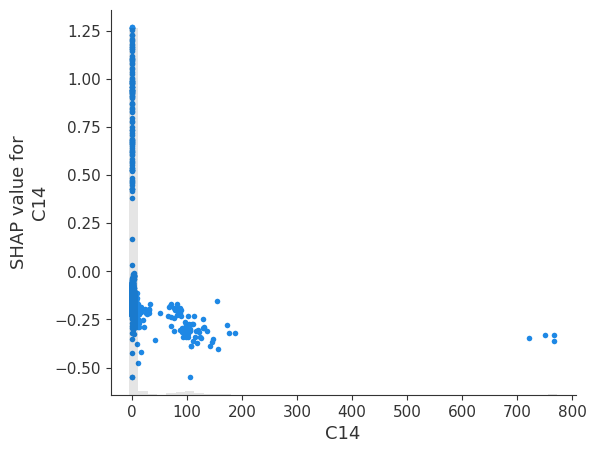

In [94]:
shap.plots.scatter(shap_values[:, top_feature])

Explain an Individual Fraud Transaction

In [95]:
y_test_array = np.asarray(y_test)

xgb_test_probs = test_probs["XGBoost"]
xgb_test_pred = (xgb_test_probs >= xgb_threshold).astype(int)
correct_fraud_idx = np.where((y_test_array == 1) & (xgb_test_pred == 1))[0]

print("Correctly detected fraud cases:", len(correct_fraud_idx))

Correctly detected fraud cases: 1737


In [96]:
fraud_position = correct_fraud_idx[0]

X_fraud = X_test_full.iloc[[fraud_position]]
fraud_shap = explainer(X_fraud)

print("Actual class:", y_test_array[fraud_position])

print("XGBoost fraud probability:", round(xgb_test_probs[fraud_position], 4))

Actual class: 1
XGBoost fraud probability: 0.9684


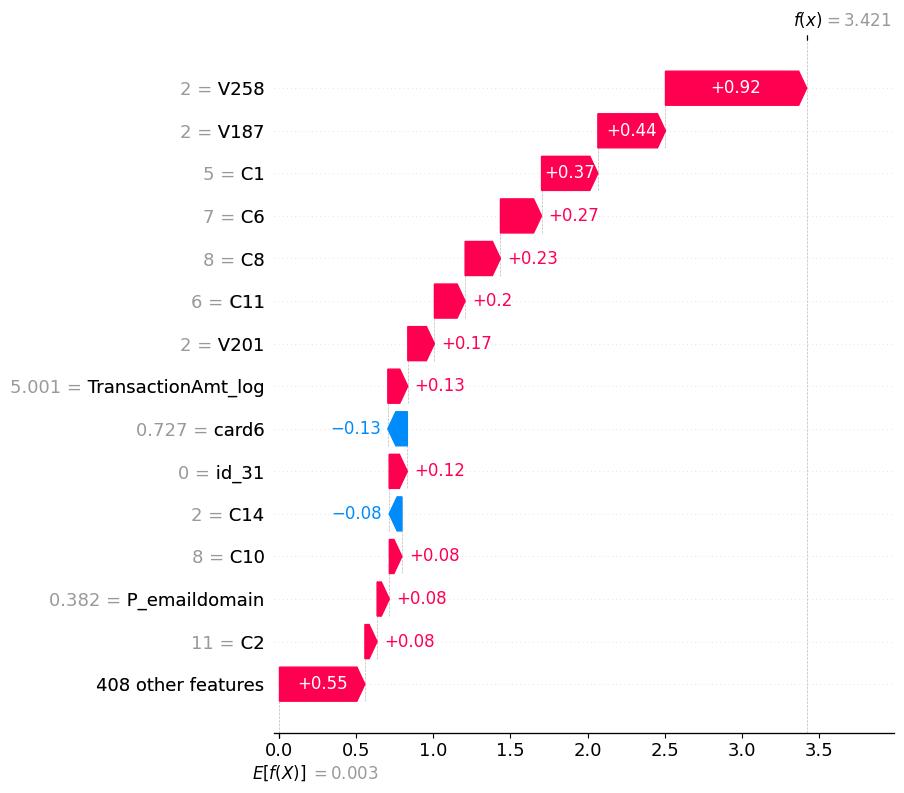

In [97]:
shap.plots.waterfall(fraud_shap[0], max_display=15)

Explain a Legitimate Transaction

In [98]:
correct_legit_idx = np.where((y_test_array == 0) & (xgb_test_pred == 0))[0]
legit_position = correct_legit_idx[0]

X_legit = X_test_full.iloc[[legit_position]]
legit_shap = explainer(X_legit)

print("Actual class:", y_test_array[legit_position])
print("XGBoost fraud probability:", round(xgb_test_probs[legit_position], 4))

Actual class: 0
XGBoost fraud probability: 0.1027


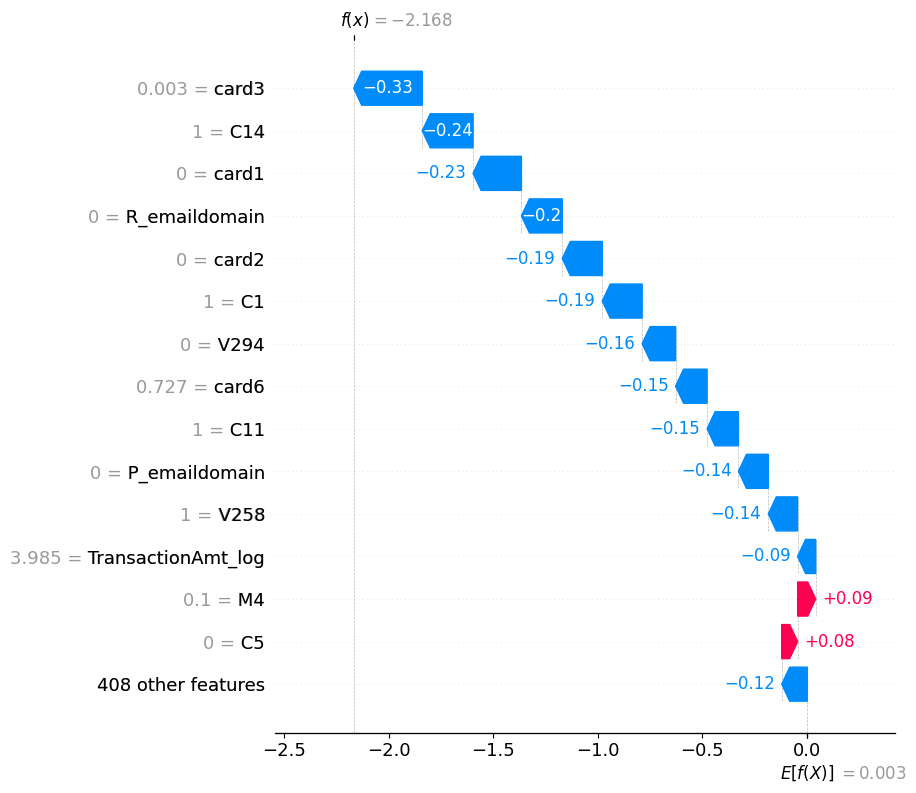

In [99]:
shap.plots.waterfall(legit_shap[0], max_display=15)

Explain the Stacking Model

In [100]:
meta_train_df = pd.DataFrame(X_meta_train, columns=stacking_models)
meta_test_df = pd.DataFrame(meta_features_test, columns=stacking_models)

In [101]:
meta_explainer = shap.LinearExplainer(meta_model, meta_train_df)
meta_sample = meta_test_df.sample(n=min(2000, len(meta_test_df)), random_state=42)
meta_shap_values = meta_explainer(meta_sample)

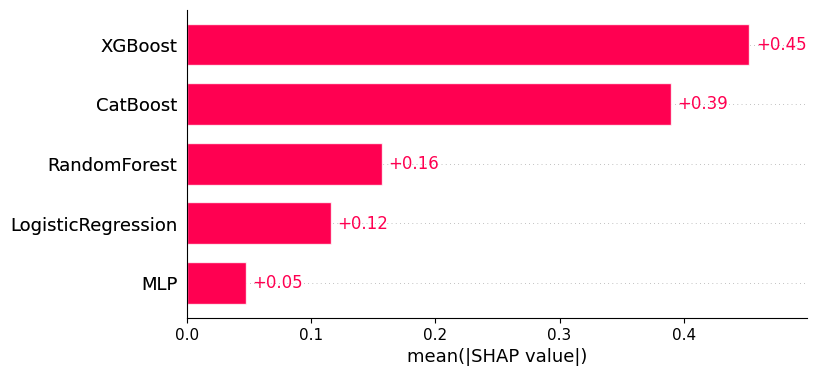

In [102]:
shap.plots.bar(meta_shap_values, max_display=5)

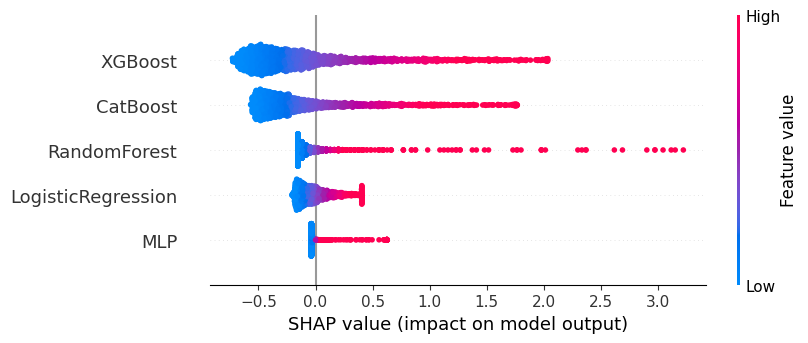

In [103]:
shap.plots.beeswarm(meta_shap_values, max_display=5)

The Stacking SHAP analysis was performed at the base-model level rather
than the original transaction-feature level. Each input to the
meta-model represented the fraud score produced by one supervised base
model.

Random Forest and XGBoost showed the strongest influence on the Stacking
output, which is consistent with their relatively large positive
meta-model coefficients. These SHAP values therefore describe how the
base-model predictions influenced the ensemble and should not be
interpreted as original transaction-feature importance.

Original feature-level interpretation was instead provided through the
XGBoost TreeSHAP analysis.

# 12. Model and Artifact Export

In [104]:
import os
import json
import joblib

#EXPORT_DIR = "fraud_app"
#ARTIFACT_DIR = f"{EXPORT_DIR}/artifacts"
#DATA_DIR = f"{EXPORT_DIR}/data"
#os.makedirs(ARTIFACT_DIR, exist_ok=True)
#os.makedirs(DATA_DIR, exist_ok=True)

ARTIFACT_DIR = BASE_DIR / "artifacts"
DATA_DIR = BASE_DIR / "data"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [105]:
# 1. Trained models (sklearn-compatible ones via joblib)
joblib.dump(log_reg_model,    f"{ARTIFACT_DIR}/log_reg.pkl")
joblib.dump(rf_model,   f"{ARTIFACT_DIR}/rf_model.pkl")
joblib.dump(xgb_model,  f"{ARTIFACT_DIR}/xgb_model.pkl")
joblib.dump(cb_model,   f"{ARTIFACT_DIR}/cb_model.pkl")
joblib.dump(mlp_model,  f"{ARTIFACT_DIR}/mlp_model.pkl")
joblib.dump(iso_forest, f"{ARTIFACT_DIR}/iso_forest.pkl")
joblib.dump(meta_model, f"{ARTIFACT_DIR}/meta_model.pkl")

# Autoencoder is a Keras model -> save it natively, not via joblib
autoencoder.save(f"{ARTIFACT_DIR}/autoencoder.keras")

joblib.dump(train_medians, f"{ARTIFACT_DIR}/train_medians.pkl")
joblib.dump(high_missing_cols, f"{ARTIFACT_DIR}/high_missing_cols.pkl")
joblib.dump(high_corr_cols, f"{ARTIFACT_DIR}/high_corr_cols.pkl")

['/Users/lata.bharati/Desktop/FraudShield/artifacts/high_corr_cols.pkl']

In [106]:
# 2. Scalers (fit on training data only -- reused as-is at inference time)
joblib.dump(scaler,     f"{ARTIFACT_DIR}/scaler.pkl")       # StandardScaler on X_train_reduced
joblib.dump(iso_scaler, f"{ARTIFACT_DIR}/iso_scaler.pkl")   # MinMaxScaler on Isolation Forest scores
joblib.dump(ae_scaler,  f"{ARTIFACT_DIR}/ae_scaler.pkl")    # MinMaxScaler on Autoencoder reconstruction error

['/Users/lata.bharati/Desktop/FraudShield/artifacts/ae_scaler.pkl']

In [107]:
# 3. Frequency-encoding maps
joblib.dump(frequency_maps, f"{ARTIFACT_DIR}/frequency_maps.pkl")


['/Users/lata.bharati/Desktop/FraudShield/artifacts/frequency_maps.pkl']

In [108]:
# 4. Metadata: feature order, thresholds, and ensemble membership
editable_fields = [
    {"name": "TransactionAmt",     "label": "Transaction amount ($)", "type": "number", "step": "0.01"},
    {"name": "ProductCD",          "label": "Product code",           "type": "select"},
    {"name": "card4",              "label": "Card network",           "type": "select"},
    {"name": "card6",              "label": "Card type",              "type": "select"},
    {"name": "P_emaildomain",      "label": "Purchaser email domain", "type": "select"},
    {"name": "DeviceType",         "label": "Device type",            "type": "select"},
    {"name": "RelativeHour",    "label": "Relative 24-hour cycle (0-23)",     "type": "number", "step": "1"},
]

metadata = {
    "feature_cols_full": list(X_train_full.columns),
    "feature_cols_reduced": list(X_train_reduced.columns),
    "model_thresholds": {k: float(v) for k, v in model_thresholds.items()},
    "voting_models": voting_models,
    "stacking_models": stacking_models,
    "editable_fields": editable_fields,
    "categorical_features": categorical_features,
    "categorical_missing_token": "MISSING",
    "transaction_amount_transform": "log1p",
}

with open(f"{ARTIFACT_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [109]:
# 5. Test set data for Flask app--These files are used by the Flask app for: live transaction replay, manual transaction templates, and runtime analytics
# TransactionID is included only for alignment and traceability. It is not used as a model feature.

# Export settings
STREAM_SAMPLE_SIZE = 3000  # Set to None to export the entire test set, or an integer to limit the number of rows exported

# Confirm that required variables exist
required_variables = ["df_sorted", "validation_end",  "test_set",  "X_test_full", "X_test_reduced", "y_test", "DATA_DIR"]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(f"These required variables are missing: {missing_variables}")

# Create output directory
os.makedirs(DATA_DIR, exist_ok=True)


# Recover the exact rows used for the chronological split
if "TransactionID" not in df_sorted.columns:
    raise KeyError(
        "TransactionID is not available in df_sorted. "
    )

if "TransactionDT" not in df_sorted.columns:
    raise KeyError(
        "TransactionDT is not available in df_sorted."
    )


# Select the original rows belonging to the chronological test set
original_test_df = (df_sorted.iloc[validation_end:].reset_index(drop=True).copy())

assert (original_test_df["TransactionID"].reset_index(drop=True).equals( test_set["TransactionID"].reset_index(drop=True))), "TransactionID order does not match the model test set."

# Extract TransactionIDs separately
test_ids = (original_test_df["TransactionID"].astype("int64").reset_index(drop=True))

# Check test-set alignment
if len(test_ids) != len(test_set):
    raise ValueError(
        f"TransactionID rows ({len(test_ids):,}) do not match "
        f"test_set rows ({len(test_set):,})."
    )

if len(test_ids) != len(X_test_full):
    raise ValueError(
        f"TransactionID rows ({len(test_ids):,}) do not match "
        f"X_test_full rows ({len(X_test_full):,})."
    )

if len(test_ids) != len(X_test_reduced):
    raise ValueError(
        f"TransactionID rows ({len(test_ids):,}) do not match "
        f"X_test_reduced rows ({len(X_test_reduced):,})."
    )

if len(test_ids) != len(y_test):
    raise ValueError(
        f"TransactionID rows ({len(test_ids):,}) do not match "
        f"y_test rows ({len(y_test):,})."
    )

# Additional chronological alignment check
if "TransactionDT" in test_set.columns:
    original_test_time = (original_test_df["TransactionDT"].reset_index(drop=True))
    model_test_time = (test_set["TransactionDT"].reset_index(drop=True))
    assert original_test_time.equals(model_test_time), (
        "The original test rows and test_set are not in the same order."
    )
print("Original test-set alignment verified.")

# Decide export size
if STREAM_SAMPLE_SIZE is None:
    n_export = len(X_test_full)
else:
    n_export = min( STREAM_SAMPLE_SIZE, len(X_test_full))

print(
    f"Preparing {n_export:,} test rows "
    "for Flask app export."
)

# Select TransactionIDs for export
test_ids_export = (test_ids.iloc[:n_export].reset_index(drop=True).astype("int64"))

# Prepare full and reduced model feature matrices
X_test_full_export = (X_test_full.reset_index(drop=True).iloc[:n_export].copy())
X_test_reduced_export = (X_test_reduced.reset_index(drop=True).iloc[:n_export].copy())

# Prevent duplicate TransactionID columns when rerunning the cell
X_test_full_export.drop(columns=["TransactionID"],errors="ignore",inplace=True)
X_test_reduced_export.drop(columns=["TransactionID"],errors="ignore",inplace=True)

# Insert TransactionID as the first column
X_test_full_export.insert(0,"TransactionID",test_ids_export.values)
X_test_reduced_export.insert(0,"TransactionID",test_ids_export.values)

# Prepare target file
y_test_export = (pd.Series(y_test).reset_index(drop=True).iloc[:n_export].astype(int))
y_test_out = pd.DataFrame({"TransactionID": test_ids_export.values,"isFraud": y_test_export.values})

# Prepare readable display file: Use original, unencoded test values for fields displayed in the app.
test_display_source = (original_test_df.iloc[:n_export].copy())
display_columns = {}
readable_features = ["TransactionAmt","ProductCD","card4","card6","P_emaildomain","R_emaildomain","DeviceType", "DeviceInfo","RelativeHour"]

for column in readable_features:
    if column in test_display_source.columns:

        if (pd.api.types.is_object_dtype(test_display_source[column])
            or pd.api.types.is_string_dtype(test_display_source[column])
            or isinstance(test_display_source[column].dtype, pd.CategoricalDtype)
        ):
            display_columns[column] = (test_display_source[column].fillna("Missing").values)
        else:
            display_columns[column] = (test_display_source[column].values)

    elif column in X_test_full_export.columns:
        display_columns[column] = (X_test_full_export[column].values)

display_df = pd.DataFrame(display_columns)
display_df.insert(0, "TransactionID", test_ids_export.values)

# Alignment checks before saving
assert len(X_test_full_export) == n_export
assert len(X_test_reduced_export) == n_export
assert len(y_test_out) == n_export
assert len(display_df) == n_export

assert (X_test_full_export["TransactionID"].reset_index(drop=True).equals(test_ids_export))
assert (X_test_reduced_export["TransactionID"].reset_index(drop=True).equals(test_ids_export))
assert (y_test_out["TransactionID"].reset_index(drop=True).equals(test_ids_export))
assert (display_df["TransactionID"].reset_index(drop=True).equals(test_ids_export))
assert (y_test_out["isFraud"].reset_index(drop=True).equals(y_test_export))

print("TransactionID and target alignment checks passed.")


# Save files
X_test_full_export.to_csv(f"{DATA_DIR}/X_test_full.csv", index=False)
X_test_reduced_export.to_csv(f"{DATA_DIR}/X_test_reduced.csv", index=False)
y_test_out.to_csv(f"{DATA_DIR}/y_test.csv", index=False)
display_df.to_csv(f"{DATA_DIR}/display_df.csv", index=False)


# Final confirmation
print("\nExport complete.")
print(f"Test rows exported: {n_export:,}")
print(f"Files saved in: {DATA_DIR}")

print("X_test_full.csv:", X_test_full_export.shape)
print("X_test_reduced.csv:", X_test_reduced_export.shape)
print("y_test.csv:", y_test_out.shape)
print("display_df.csv:", display_df.shape)
 

if "ARTIFACT_DIR" in globals():
    print(
        f"Copy '{ARTIFACT_DIR}' and "
        f"'{DATA_DIR}' into Flask app folder."
    )

if "editable_fields" in globals():
    print(
        "Editable fields included:",
        [field["name"] for field in editable_fields]
    )

Original test-set alignment verified.
Preparing 3,000 test rows for Flask app export.
TransactionID and target alignment checks passed.

Export complete.
Test rows exported: 3,000
Files saved in: /Users/lata.bharati/Desktop/FraudShield/data
X_test_full.csv: (3000, 423)
X_test_reduced.csv: (3000, 345)
y_test.csv: (3000, 2)
display_df.csv: (3000, 10)
Copy '/Users/lata.bharati/Desktop/FraudShield/artifacts' and '/Users/lata.bharati/Desktop/FraudShield/data' into Flask app folder.
Editable fields included: ['TransactionAmt', 'ProductCD', 'card4', 'card6', 'P_emaildomain', 'DeviceType', 'RelativeHour']


In [110]:
# Export SHAP background datasets for Flask application
SHAP_BACKGROUND_SIZE = 200

# Background for models using the full feature set
shap_background_full = X_train_full.sample(n=min(SHAP_BACKGROUND_SIZE, len(X_train_full)), random_state=42).copy()

# Background for models using the reduced feature set
shap_background_reduced = X_train_reduced.sample(n=min(SHAP_BACKGROUND_SIZE, len(X_train_reduced)), random_state=42).copy()

# Background for Soft Voting / Stacking
shap_background_meta = pd.DataFrame(X_meta_train, columns=stacking_models).sample(n=min(SHAP_BACKGROUND_SIZE, len(X_meta_train)), random_state=42).copy()

# Save
shap_background_full.to_csv(f"{DATA_DIR}/shap_background_full.csv", index=False)
shap_background_reduced.to_csv(f"{DATA_DIR}/shap_background_reduced.csv", index=False)
shap_background_meta.to_csv(f"{DATA_DIR}/shap_background_meta.csv", index=False)

print("SHAP background files exported:")
print(shap_background_full.shape)
print(shap_background_reduced.shape)
print(shap_background_meta.shape)

SHAP background files exported:
(200, 422)
(200, 344)
(200, 5)


# 13. Sensitivuity ananlysis of missing threshold

In [111]:
def prepare_for_missingness_sensitivity(train_df, valid_df, test_df, missing_cutoff):
    # Creating copies to avoid modifying the original DataFrames
    train = train_df.copy()
    valid = valid_df.copy()
    test = test_df.copy()

    # To ensure log transaction amount exists
    for data in [train, valid, test]:
        if "TransactionAmt_log" not in data.columns and "TransactionAmt" in data.columns:
            data["TransactionAmt_log"] = np.log1p(data["TransactionAmt"])

        if "TransactionAmt" in data.columns:
            data.drop(columns=["TransactionAmt"], inplace=True)

        # To ensure relative time features exist
        if "RelativeHour" not in data.columns:
            data["RelativeHour"] = (data["TransactionDT"] // 3600) % 24

        if "RelativeWeekday" not in data.columns:
            data["RelativeWeekday"] = (
                data["TransactionDT"] // (3600 * 24)
            ) % 7

    y_train_s = train["isFraud"].copy()
    y_valid_s = valid["isFraud"].copy()
    y_test_s = test["isFraud"].copy()

    drop_cols = ["TransactionID", "TransactionDT", "isFraud"]

    X_train_s = train.drop(columns=[c for c in drop_cols if c in train.columns]).copy()
    X_valid_s = valid.drop(columns=[c for c in drop_cols if c in valid.columns]).copy()
    X_test_s = test.drop(columns=[c for c in drop_cols if c in test.columns]).copy()

    # Missingness learned from TRAINING DATA ONLY
    missing_pct = X_train_s.isnull().mean() * 100

    cols_to_drop = missing_pct[missing_pct > missing_cutoff].index.tolist()

    X_train_s.drop(columns=cols_to_drop, inplace=True)
    X_valid_s.drop(columns=cols_to_drop, inplace=True)
    X_test_s.drop(columns=cols_to_drop, inplace=True)

    # Reconstruct categorical feature list
    categorical_candidates = (["ProductCD"] + [f"card{i}" for i in range(1, 7)] + ["addr1", "addr2", "P_emaildomain", "R_emaildomain"] + [f"M{i}" for i in range(1, 10)]
                               + ["DeviceType", "DeviceInfo"] + [f"id_{i:02d}" for i in range(12, 39)])

    categorical_s = [
        c for c in categorical_candidates
        if c in X_train_s.columns
    ]

    # Frequency encoding learned from TRAINING DATA 
    for col in categorical_s:
        X_train_s[col] = (X_train_s[col].astype("string").fillna("MISSING"))
        X_valid_s[col] = (X_valid_s[col].astype("string").fillna("MISSING"))
        X_test_s[col] = (X_test_s[col].astype("string").fillna("MISSING"))

        freq_map = X_train_s[col].value_counts(normalize=True)

        X_train_s[col] = X_train_s[col].map(freq_map)
        X_valid_s[col] = (X_valid_s[col].map(freq_map).fillna(0))
        X_test_s[col] = (X_test_s[col].map(freq_map).fillna(0))

    # Median imputation learned from TRAINING DATA 
    train_medians_s = X_train_s.median().fillna(0)

    X_train_s = X_train_s.fillna(train_medians_s)
    X_valid_s = X_valid_s.fillna(train_medians_s)
    X_test_s = X_test_s.fillna(train_medians_s)

    return (X_train_s, X_valid_s, X_test_s, y_train_s, y_valid_s, y_test_s, cols_to_drop)

In [112]:
missingness_cutoffs = [80, 90, 95]

sensitivity_results = []

for cutoff in missingness_cutoffs:

    (X_tr, X_va, X_te, y_tr, y_va, y_te, dropped_cols) = prepare_for_missingness_sensitivity(train_set, valid_set, test_set, cutoff)

    # -------------XGBoost model for sensitivity analysis----------------
    # Count positive and negative samples in training set
    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()

    xgb_sensitivity_model = XGBClassifier(max_depth=6, n_estimators=200, learning_rate=0.05, scale_pos_weight=neg / pos, random_state=42, eval_metric="logloss", n_jobs=-1)
    xgb_sensitivity_model.fit(X_tr, y_tr)

    xgb_val_probs_s = xgb_sensitivity_model.predict_proba(X_va)[:, 1]
    xgb_test_probs_s = xgb_sensitivity_model.predict_proba(X_te)[:, 1]

    sensitivity_results.append({
        "Model": "XGBoost",
        "Missingness Cutoff": cutoff,
        "Features Retained": X_tr.shape[1],
        "Features Removed": len(dropped_cols),
        "Validation PR-AUC":
            average_precision_score(y_va, xgb_val_probs_s),
        "Test PR-AUC":
            average_precision_score(y_te, xgb_test_probs_s)
    })

    # -------------CatBoost model for sensitivity analysis----------------
    cb_sensitivity_model = CatBoostClassifier(depth=12, iterations=200, auto_class_weights="Balanced",learning_rate=0.05, random_seed=42, verbose=0)
    cb_sensitivity_model.fit(X_tr, y_tr)

    cb_val_probs_s = cb_sensitivity_model.predict_proba(X_va)[:, 1]
    cb_test_probs_s = cb_sensitivity_model.predict_proba(X_te)[:, 1]

    sensitivity_results.append({
        "Model": "catBoost",
        "Missingness Cutoff": cutoff,
        "Features Retained": X_tr.shape[1],
        "Features Removed": len(dropped_cols),
        "Validation PR-AUC": average_precision_score(y_va, cb_val_probs_s),
        "Test PR-AUC": average_precision_score(y_te, cb_test_probs_s)
    })

sensitivity_results = pd.DataFrame(sensitivity_results)

display(sensitivity_results.round(4))

,Model,Missingness Cutoff,Features Retained,Features Removed,Validation PR-AUC,Test PR-AUC
0,XGBoost,80,360,74,0.5435,0.4561
1,catBoost,80,360,74,0.5466,0.4477
2,XGBoost,90,422,12,0.5442,0.4599
3,catBoost,90,422,12,0.5558,0.4609
4,XGBoost,95,425,9,0.5451,0.4613
5,catBoost,95,425,9,0.5494,0.4488
